# Team Information

#### **Nama Tim:** LastWorgxhx

#### **Nama Anggota Tim:**
1. Nathaniel Jonathan Rusli
2. Maheswara Bayu Kaindra
3. Peter Wongsoredjo

# Import Libraries and Configurations

In [1]:
# Data Manipulation and Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML Model
import catboost as cb
import xgboost as xgb
import lightgbm as lgb

# Preprocessing and Validation
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

# Model Explanation
import shap

# Other
import ast
import re
import unicodedata
from scipy import sparse
from collections import Counter
from collections import defaultdict

In [2]:
# Matplotlib & Seaborn
%matplotlib inline
sns.set_context("notebook", font_scale=0.9)
sns.set_style("white")
sns.set_palette("mako")

# Pandas
pd.set_option('display.max_columns', 500)

# SHAP
shap.initjs()

# Random
RANDOM_SEED = 1
np.random.seed(RANDOM_SEED)

# Exploratory Data Analysis (EDA)

### Domain Knowledge: Feature Understanding

Pada dataset **train.csv**, terdapat sejumlah fitur yang merepresentasikan informasi dari CV kandidat.  
Berikut penjelasan singkat mengenai masing-masing fitur:

---

#### ID
- Identifier unik untuk setiap kandidat.
- Tidak mengandung informasi prediktif → biasanya di-drop dari modeling.

#### Current Position
- Posisi/jabatan terakhir yang dijalani kandidat.
- Memberi gambaran senioritas dan bidang kerja aktual.

#### Targeted Position
- Posisi yang diincar kandidat.
- Penting untuk memodelkan ekspektasi gaji, karena gaji target sering berbeda dengan gaji posisi saat ini.

#### Total Working Experience
- Jumlah tahun pengalaman kerja kandidat.
- Salah satu faktor paling berpengaruh terhadap gaji (semakin lama pengalaman, umumnya semakin tinggi gaji).

#### Candidate Level
- Kategori senioritas (misal: Fresher, Junior, Mid-Level, Senior).
- Memberi konteks tambahan selain “Total Working Experience”.

#### Domisili
- Lokasi tempat tinggal kandidat.
- Penting karena gaji sering bergantung pada cost of living dan standar upah regional.

#### Education 1, 2, 3
- Riwayat pendidikan formal (misalnya S1, S2).
- Kualitas dan level pendidikan memengaruhi besaran gaji awal serta peluang kerja.

#### Expected Benefit Bottom / Up
- Rentang ekspektasi gaji yang diinginkan kandidat.
- Memberi informasi langsung tentang target gaji kandidat; dapat membantu model memahami bias/harapan kandidat.

#### Notice Period
- Lama waktu yang dibutuhkan kandidat untuk mulai bekerja setelah menerima tawaran.
- Bisa memengaruhi daya tawar kandidat, walaupun pengaruh terhadap gaji relatif kecil.

#### Tech Stack
- Daftar teknologi/tools yang dikuasai kandidat.
- Relevan untuk mengukur “market value” kandidat dalam bidang IT/software development.

#### Certification
- Sertifikasi profesional yang dimiliki kandidat.
- Menunjukkan kredibilitas skill tertentu (mis. cloud, database, agile).

#### Estimate Bottom / Up
- Target variabel (label) yang ingin diprediksi.
- Merupakan estimasi gaji terendah dan tertinggi kandidat yang tersedia sebagai ground truth.

### Dataset Overview

In [3]:
train_df = pd.read_csv("/kaggle/input/salary-prediction-model/train.csv")
test_df = pd.read_csv("/kaggle/input/salary-prediction-model/test.csv")

In [4]:
print(train_df.shape)
print(test_df.shape)

(1160, 16)
(290, 14)


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1160 entries, 0 to 1159
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        1160 non-null   object 
 1   Current Position          1019 non-null   object 
 2   Targeted Position         202 non-null    object 
 3   Total Working Experience  1160 non-null   int64  
 4   Candidate Level           1160 non-null   object 
 5   Domisili                  1061 non-null   object 
 6   Education 1               1142 non-null   object 
 7   Education 2               531 non-null    object 
 8   Education 3               129 non-null    object 
 9   Expected Benefit Botom    1160 non-null   int64  
 10  Expected Benefit Up       1160 non-null   int64  
 11  Notice Period             57 non-null     object 
 12  Tech Stack                1155 non-null   object 
 13  Certification             801 non-null    object 
 14  Estimate

Terlihat terdapat typo pada feature "Expected Benefit Botom", mari kita perbaiki...

In [6]:
train_df = train_df.rename(columns={"Expected Benefit Botom": "Expected Benefit Bottom"})

In [7]:
train_df.describe()

,Total Working Experience,Expected Benefit Bottom,Expected Benefit Up,Estimate Bottom,Estimate Up
count,1160.000000,1.160000e+03,1.160000e+03,1.160000e+03,1.160000e+03
mean,3.126724,4.212931e+05,1.681897e+05,7.602155e+06,1.182543e+07
std,2.830618,2.148195e+06,1.413114e+06,3.705119e+06,6.002688e+06
min,0.000000,0.000000e+00,0.000000e+00,2.500000e+06,4.000000e+06
25%,1.000000,0.000000e+00,0.000000e+00,5.000000e+06,8.000000e+06
50%,3.000000,0.000000e+00,0.000000e+00,8.000000e+06,1.200000e+07
75%,4.000000,0.000000e+00,0.000000e+00,8.000000e+06,1.200000e+07
max,19.000000,2.150000e+07,2.300000e+07,3.500000e+07,5.500000e+07


In [8]:
train_df.head()

,ID,Current Position,Targeted Position,Total Working Experience,Candidate Level,Domisili,Education 1,Education 2,Education 3,Expected Benefit Bottom,Expected Benefit Up,Notice Period,Tech Stack,Certification,Estimate Bottom,Estimate Up
0,SKU-WENU1319,Web Developer,NaN,2,Junior,Bandung,UNIVERSITAS TERBUKA (2023-2027)\nBachelor of S...,SMK Negeri 2 Tasikmalaya (2019 - 2023)\nSistem...,NaN,0,0,NaN,"HTML ,CSS ,Javascript(ReactJs) ,Jquery ,Ajax ,...","[""Junior Web Developer, Digitalent Scholarship...",6000000.0,9000000.0
1,SKU-FUNU1303,Full Stack Developer,NaN,1,Mid-Level,Bandung,Padjadjaran University 2017-2021,NaN,NaN,0,0,NaN,"Laravel, Phalcon, Python, Django, Next.Js, Tai...","[""Google Data Analytics, Coursera Jul 2023"",""L...",8000000.0,12000000.0
2,SKU-JUNU1052,Junior Web Developer,NaN,0,Junior,"Semarang, Jawa Tengah",Universitas Negeri Semarang (2019 - 2024)\nS1 ...,Purwadhika Digital Technology School (2024)\nF...,NaN,0,0,NaN,"JavaScript, Prisma ORM, TypeScript, MySQL, Rea...","[""Full-stack Web Developer""]",4000000.0,6000000.0
3,SKU-JANU420,Java Developer,NaN,0,Junior,Bandung,"Bachelor's degree, Universitas Pendidikan Indo...",NaN,NaN,0,0,NaN,"React, JavaScript, Mobile Application Software...",[],6000000.0,9000000.0
4,SKU-NUNU1182,NaN,NaN,4,Mid-Level,Bandung,"Ilmu Komputer, Universitas Pendidikan Indonesi...",NaN,NaN,0,0,NaN,"PHP, Python, Java, Javascript, Go, C#, Laravel...",[],8000000.0,12000000.0


Berdasarkan observasi di atas, feature seperti Current Position (yang berkorespondensi dengan Targeted Position), Domisili Level, Education 1, 2, 3, Tech Stack, dan Certification memiliki kardinalitas yang sangat tinggi. Kami akan observasi masing-masing feature dengan lebih lanjut...

In [9]:
train_df.nunique()

ID                          1160
Current Position             549
Targeted Position             21
Total Working Experience      18
Candidate Level                5
Domisili                     436
Education 1                 1122
Education 2                  519
Education 3                  124
Expected Benefit Bottom       24
Expected Benefit Up           13
Notice Period                 17
Tech Stack                  1144
Certification                442
Estimate Bottom               16
Estimate Up                   25
dtype: int64

### NaN Data

Dataset ini juga tampak memiliki missing values pada feature tertentu yang kemungkinan besar tidak available pada CV pelamar kerja...

In [10]:
train_df.isna().sum()

ID                             0
Current Position             141
Targeted Position            958
Total Working Experience       0
Candidate Level                0
Domisili                      99
Education 1                   18
Education 2                  629
Education 3                 1031
Expected Benefit Bottom        0
Expected Benefit Up            0
Notice Period               1103
Tech Stack                     5
Certification                359
Estimate Bottom                0
Estimate Up                    0
dtype: int64

### Duplicate Data

In [11]:
train_df.duplicated().sum()

0

### Correlation

Berdasarkan data numerik, tampak hanya terdapat korelasi kuat pada Total Working Experience terhadap target (Estimate Bottom and Estimate Up)

Text(0.5, 1.0, 'Heatmap Korelasi Fitur Numerik')

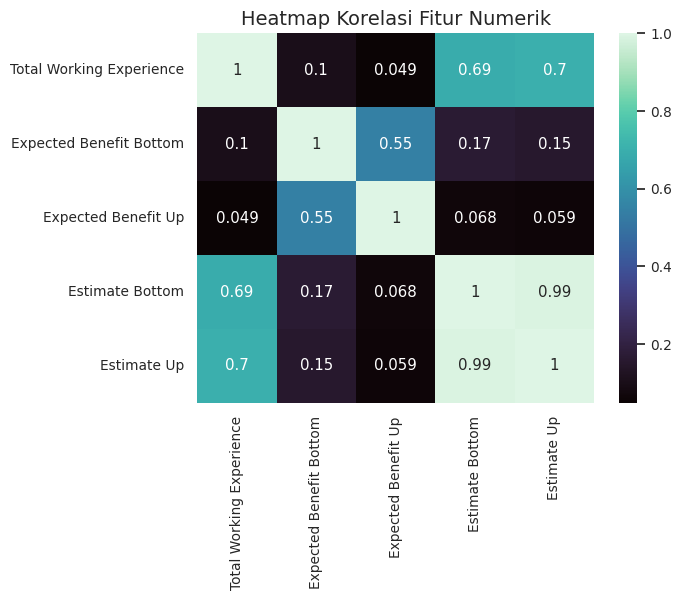

In [12]:
sns.heatmap(train_df.corr(numeric_only=True), annot=True, cmap="mako")
plt.title("Heatmap Korelasi Fitur Numerik", fontsize=14)

### Estimate Bottom and Estimate Up (Target)

Tampak pada plotting di bawah, meskipun prediksi rentang gaji ini merupakan task regression, tapi hasil berupa suatu batasan determined seperti data kategorial... hasil regresi harus dibulatkan pada nilai rentang yang ada...

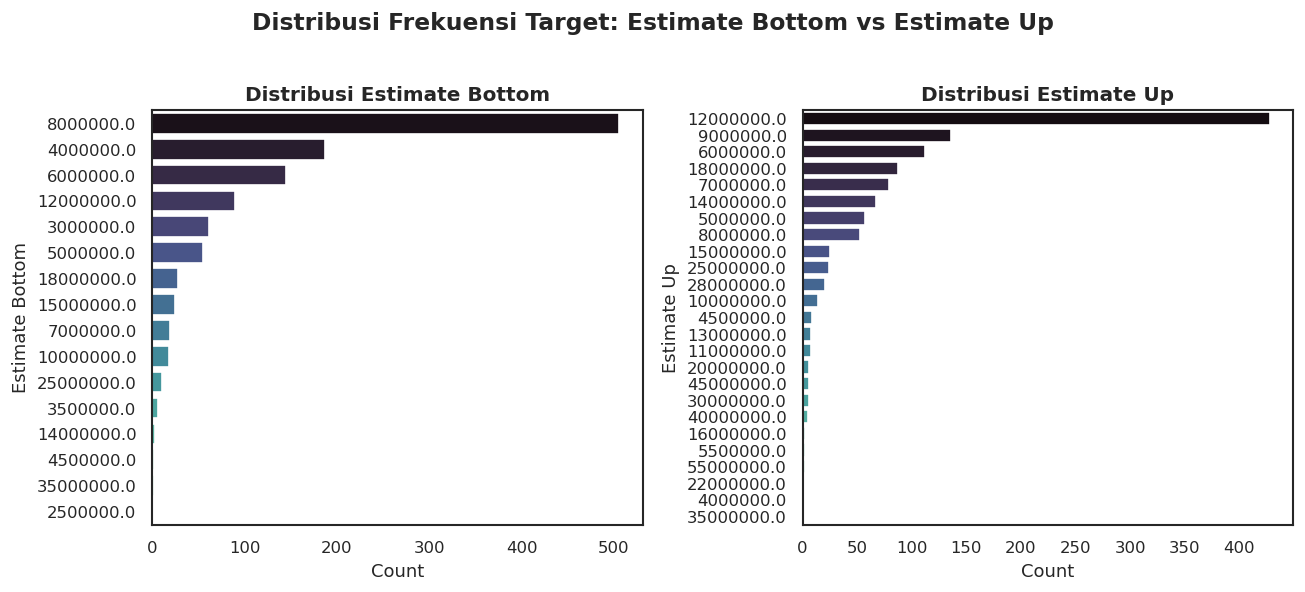

In [13]:
plt.figure(figsize=(11, 5), dpi=120)
plt.subplot(1, 2, 1)
sns.countplot(
    y="Estimate Bottom",
    data=train_df,
    order=train_df["Estimate Bottom"].value_counts().index,
    palette="mako"
)
plt.title("Distribusi Estimate Bottom", fontsize=12, fontweight="bold")
plt.xlabel("Count")
plt.ylabel("Estimate Bottom")

plt.subplot(1, 2, 2)
sns.countplot(
    y="Estimate Up",
    data=train_df,
    order=train_df["Estimate Up"].value_counts().index,
    palette="mako"
)
plt.title("Distribusi Estimate Up", fontsize=12, fontweight="bold")
plt.xlabel("Count")
plt.ylabel("Estimate Up")

plt.suptitle("Distribusi Frekuensi Target: Estimate Bottom vs Estimate Up",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("estimate_bottom_up_countplot.png", dpi=150, bbox_inches="tight")
plt.show()


### Candidate Level

Masing-masing Candidate Level memiliki tingkatan gaji yang kontras...

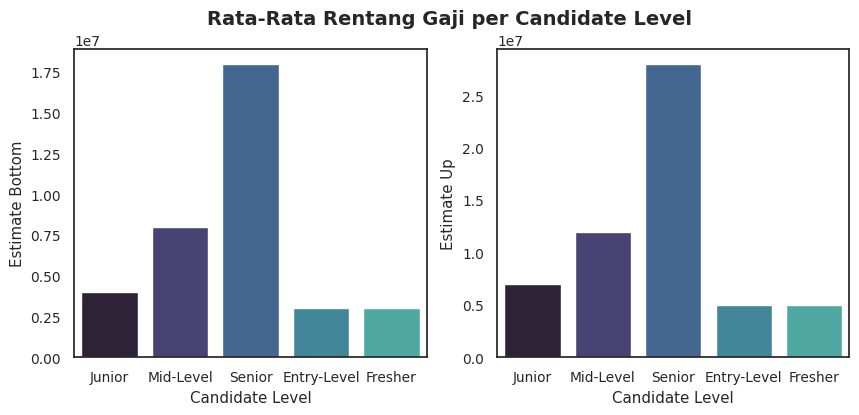

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
sns.barplot(data=train_df, x="Candidate Level", y="Estimate Bottom", estimator=np.median, ax=ax[0])
sns.barplot(data=train_df, x="Candidate Level", y="Estimate Up", estimator=np.median, ax=ax[1])
plt.suptitle("Rata-Rata Rentang Gaji per Candidate Level", fontsize=14, fontweight="bold")
plt.savefig("candidate_level_bar.png", dpi=150, bbox_inches="tight")

### Total Working Experience

Terdapat tren positif antara Total Working Experience dengan target...

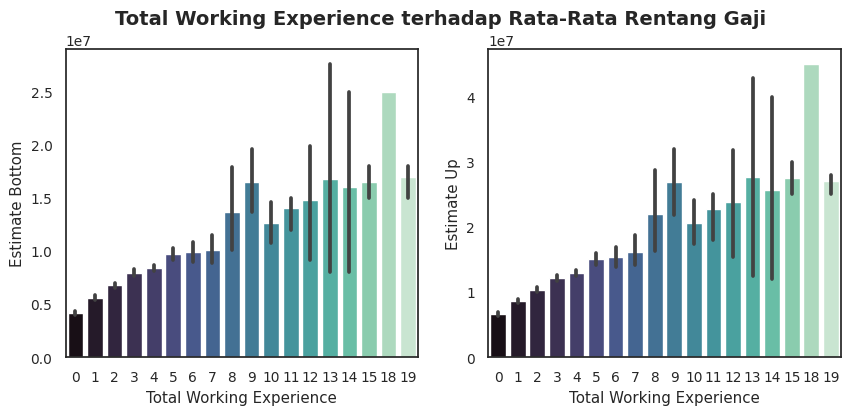

In [15]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
sns.barplot(data=train_df, x="Total Working Experience", y="Estimate Bottom", ax=ax[0], palette="mako")
sns.barplot(data=train_df, x="Total Working Experience", y="Estimate Up", ax=ax[1], palette="mako")
plt.suptitle("Total Working Experience terhadap Rata-Rata Rentang Gaji", fontsize=14, fontweight="bold")
plt.savefig("total_working_experience_bar.png", dpi=150, bbox_inches="tight")

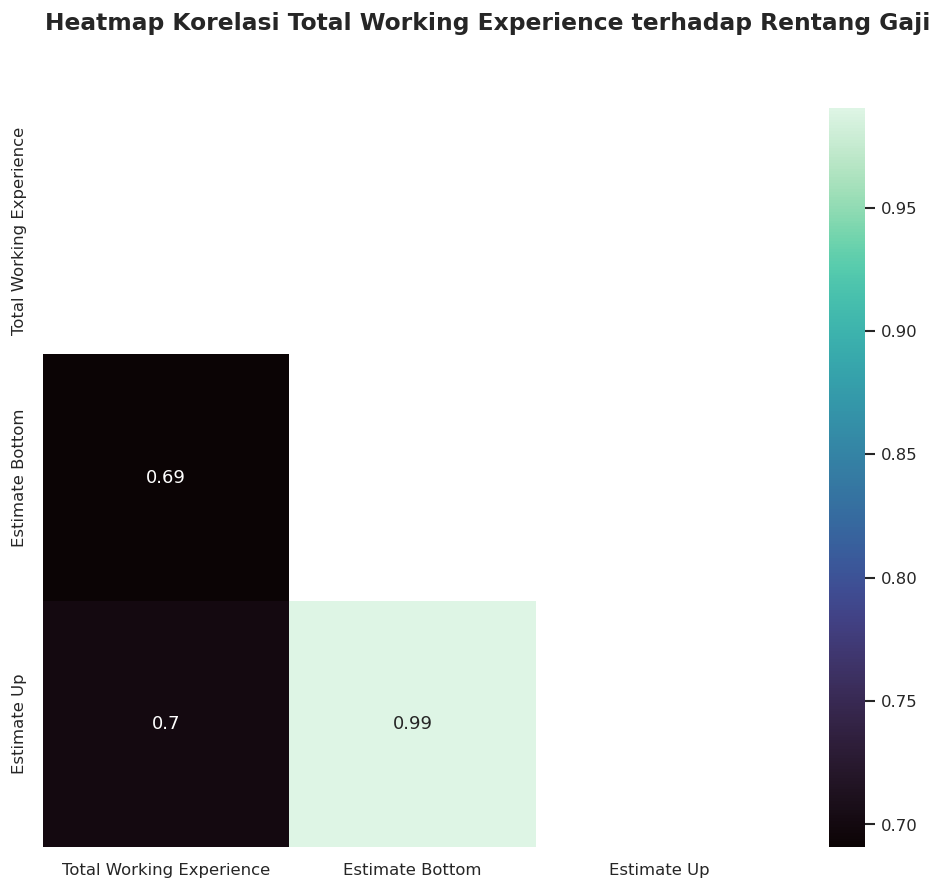

In [16]:
X_heatmap = train_df[["Total Working Experience", "Estimate Bottom", "Estimate Up"]]
corr = X_heatmap.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10,8), dpi=120)
sns.heatmap(
    corr, 
    mask=mask,      
    annot=True, 
    cmap="mako", 
    square=True
)
plt.suptitle("Heatmap Korelasi Total Working Experience terhadap Rentang Gaji", fontsize=14, fontweight="bold")
plt.savefig("total_working_experience_corr.png", dpi=150, bbox_inches="tight")
plt.show()

<Axes: xlabel='Total Working Experience', ylabel='count'>

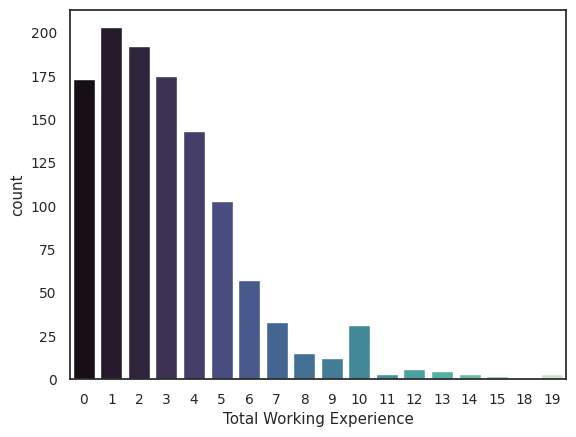

In [17]:
sns.countplot(data=train_df, x="Total Working Experience", palette="mako")

### Expected Benefit

Ekspektasi gaji yang lebih tinggi kadang kali memberikan gaji yang lebih tinggi pula...

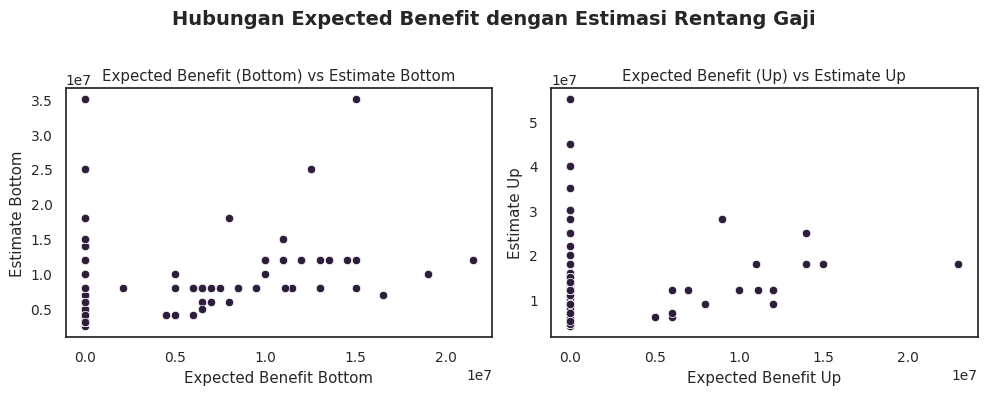

In [18]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

sns.scatterplot(data=train_df, x="Expected Benefit Bottom", y="Estimate Bottom", ax=ax[0])
ax[0].set_title("Expected Benefit (Bottom) vs Estimate Bottom")

sns.scatterplot(data=train_df, x="Expected Benefit Up", y="Estimate Up", ax=ax[1])
ax[1].set_title("Expected Benefit (Up) vs Estimate Up")

fig.suptitle("Hubungan Expected Benefit dengan Estimasi Rentang Gaji", fontsize=14, fontweight="bold")
plt.savefig("expected_scatter.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

### Notice Period

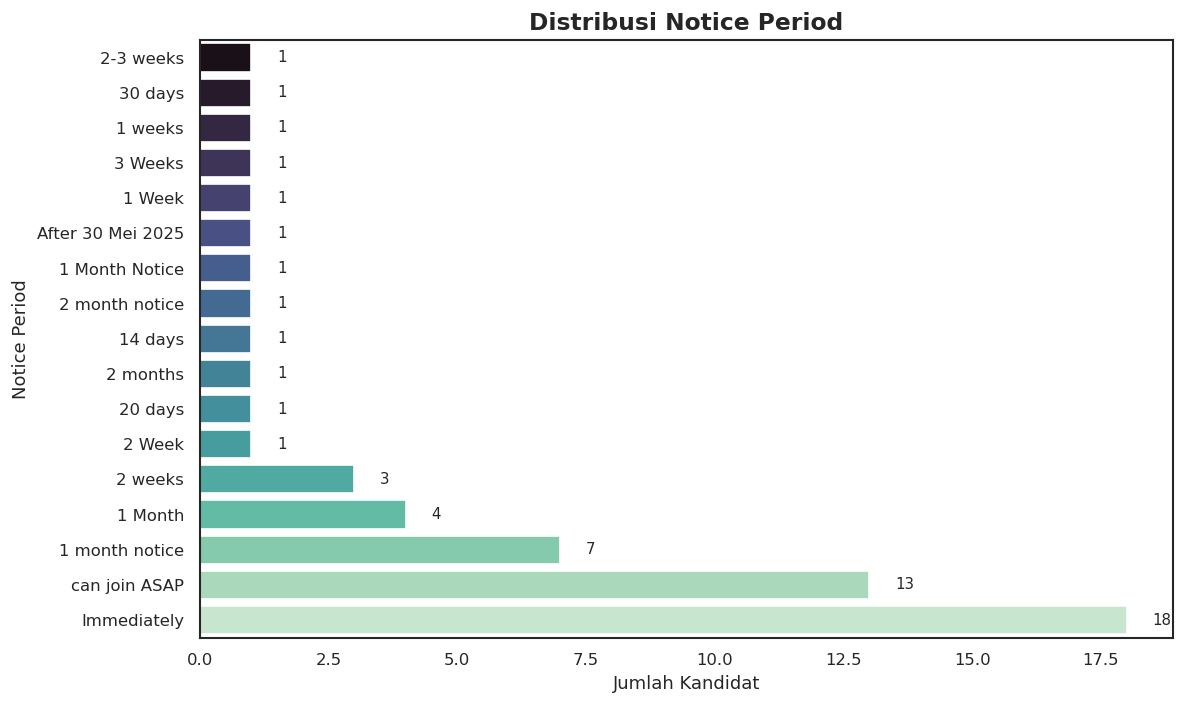

In [19]:
notice_counts = train_df["Notice Period"].value_counts().sort_values(ascending=True)

# Plot horizontal bar
plt.figure(figsize=(10, 6), dpi=120)
sns.barplot(
    x=notice_counts.values,
    y=notice_counts.index,
    palette="mako"
)

# Judul dan label
plt.title("Distribusi Notice Period", fontsize=14, fontweight="bold")
plt.xlabel("Jumlah Kandidat")
plt.ylabel("Notice Period")

# Tambahkan anotasi nilai
for i, v in enumerate(notice_counts.values):
    plt.text(v + 0.5, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig("notice_period_bar", dpi=150, bbox_inches="tight")
plt.show()

### Data with High Cardinality: Position, Domisili, Education, Tech Stack, Certification

Value yang sangat beragam menyebabkan kardinalitas yang sangat tinggi, segmentasi dapat menjadi pemrosesan data yang menjanjikan...

#### Current and Targeted Position

In [20]:
train_df["Current Position"].value_counts()

Current Position
Full Stack Developer                    43
Software Engineer                       39
Backend Developer                       37
Fullstack Developer                     33
Web Developer                           24
                                        ..
full stack engineer                      1
SQA Manual/Automation - Contract         1
Engineering Lead & Backend Developer     1
Frontend React Native Developer          1
IT & Programmer Executive                1
Name: count, Length: 549, dtype: int64

In [21]:
train_df["Targeted Position"].value_counts()

Targeted Position
Backend Developer        55
Fullstack Developer      35
Functional Tester        15
Content Creator          14
QA                       11
Android Developer        10
Admin                     9
System Analyst            8
Technical Writer          7
iOS Developer             7
Frontend Developer        6
Content Writer Intern     6
Sales Support             4
Mobile Developer          3
Teknisi                   3
Teknisi Wiring            2
Quality Assurance         2
Java Developer            2
Jr. QA Manual             1
Biofarma                  1
IT Support                1
Name: count, dtype: int64

In [22]:
train_df[["Current Position", "Targeted Position"]].head(10)

,Current Position,Targeted Position
0,Web Developer,NaN
1,Full Stack Developer,NaN
2,Junior Web Developer,NaN
3,Java Developer,NaN
4,NaN,NaN
5,Technical Writer,Technical Writer
6,Full-stack Software Engineer/Mobile App Engineer,NaN
7,NaN,Android Developer
8,Software Quality Assurance Manual Tester,NaN
9,NaN,NaN


#### Domisili

Value Domisili sangat beragam, di mana suatu tempat dapat memiliki varian value...

In [23]:
train_df["Domisili"].value_counts()

Domisili
Bandung                       94
Jakarta, Indonesia            77
Jakarta                       56
Bandung, Indonesia            35
Bandung, Jawa Barat           19
                              ..
Jakarta Selatan, Indonesia     1
Pemalang                       1
Probolinggo, Indonesia         1
Tangerang - Banten             1
Pasuruan, Indonesia            1
Name: count, Length: 436, dtype: int64

In [24]:
train_df["Domisili"].unique()[:25]

array(['Bandung', 'Semarang, Jawa Tengah', 'Mataram',
       'Palembang, Indonesia', 'Jakarta, Indonesia', nan,
       'Bandung, West Java, Indonesia', 'Bogor, West Java', 'Yogyakarta',
       'Semarang', 'Kabupaten Bandung', 'Denpasar, Bali - Indonesia',
       'Jakarta', 'Central Jakarta, DKI Jakarta',
       'Samarinda, East Kalimantan', 'Jakarta Barat',
       'Kendal, Jawa Tengah', 'WEST JAKARTA, INDONESIA',
       'Kota Jakarta Selatan', 'Semarang, Central Java',
       'East Jakarta, Indonesia', 'Tangerang', 'Bandung, Indonesia',
       'Bengkulu, Indonesia', 'Kota Bandung'], dtype=object)

#### Education

Tidak seluruh pelamar memiliki jenjang atau jumlah pendidikan yang serupa...

In [25]:
train_df[["Education 1", "Education 2", "Education 3"]].head(10)

,Education 1,Education 2,Education 3
0,UNIVERSITAS TERBUKA (2023-2027)\nBachelor of S...,SMK Negeri 2 Tasikmalaya (2019 - 2023)\nSistem...,NaN
1,Padjadjaran University 2017-2021,NaN,NaN
2,Universitas Negeri Semarang (2019 - 2024)\nS1 ...,Purwadhika Digital Technology School (2024)\nF...,NaN
3,"Bachelor's degree, Universitas Pendidikan Indo...",NaN,NaN
4,"Ilmu Komputer, Universitas Pendidikan Indonesi...",NaN,NaN
5,Politeknik Negeri Subang - Associate Degree in...,NaN,NaN
6,"STMIK AKAKOM, Yogyakarta, ID, Information Tech...",NaN,NaN
7,"Sriwijaya University - Palembang, Indonesia Au...","Bangkit Academy by Google, Tokopedia & Travelo...",NaN
8,Universitas Indraprasta PGRI - S1 (Strata 1) T...,NaN,NaN
9,INSTITUT TEKNOLOGI NASIONAL BANDUNG (AUG 2016 ...,"BINAR ACADEMY, IN PROGRESS (AUG 2022 - DES 202...",NaN


#### Tech Stack

In [26]:
train_df["Tech Stack"].sample(10)

946         Android, Kotlin, Java, SQL, Spring Boot, PHP
202    Flowchart, ERD, UML, Mockup, HTML, PHP, C++, B...
663    Cloud, Java, Spring Boot, REST, SQL, NoSQL, PH...
764    Manual Testing, Excel office, Microsoft Office...
437    C, Java, Javascript, PHP, MySQL, MongoDb, Lara...
932    Go, C++, Python, Java, JavaScript, Docker, Pos...
553    Java, PHP, JavaScript, NodeJS, Go, SQL, Spring...
81     Go, .NET (C#, VB), Java, PHP, C++, MongoDB, MY...
220    HTML, CSS, JavaScript, Java, PHP, SQL, Bootstr...
774    HTML/CSS, Javascript, Typescript, React, NextJ...
Name: Tech Stack, dtype: object

#### Certification

In [27]:
train_df["Certification"].sample(10)

1159    ["Sertifikat Kompetensi Pemograman Komputer","...
690     ["Website Programmer Certification (APTI) Grad...
1117                                                  NaN
667                                                    []
601                                                    []
736                                                   NaN
694                                                    []
56      ["Web Responsive Design - Free Code Camp - 202...
50                 ["Vaksinasi Merdeka Polda Metro Jaya"]
86      ["Microsoft AI Engineer Associate – Microsoft ...
Name: Certification, dtype: object

### Estimated Bottom and Up

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.


<Axes: ylabel='Estimate Up'>

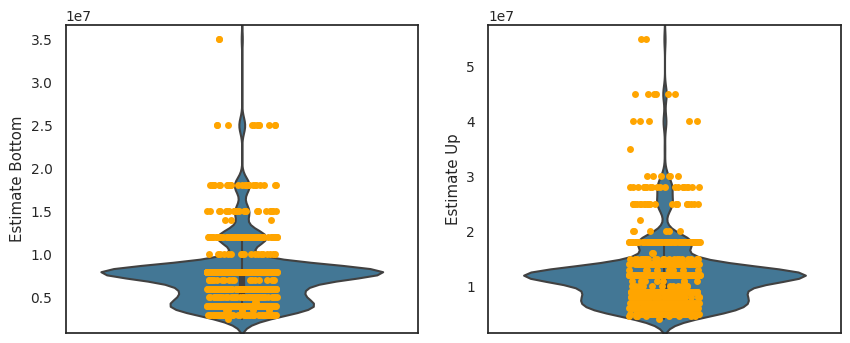

In [28]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
sns.violinplot(data=train_df, y="Estimate Bottom", ax=ax[0], palette="mako")
sns.stripplot(data=train_df, y="Estimate Bottom", ax=ax[0], color="orange")
sns.violinplot(data=train_df, y="Estimate Up", ax=ax[1], palette="mako")
sns.stripplot(data=train_df, y="Estimate Up", ax=ax[1], color="orange")

# Feature Engineering

Berdasarkan observasi terhadap data sebelumnya, dilakukan feature engineering yang menghasilkan feature yang lebih informatif dan interpretable seperti berikut...

### Current and Targeted Position

Dilakukan segmentasi yang lebih general terhadap posisi untuk mengurangi kardinalitas...

In [29]:
def clean_title(text: str) -> str:
    if pd.isna(text) or str(text).strip() == "":
        return "unknown"
    s = str(text).lower()

    # remove content in parentheses/brackets
    s = re.sub(r"\(.*?\)|\[.*?\]|\{.*?\}", " ", s)

    # unify connectors to spaces
    s = s.replace("&", " ")
    s = s.replace("/", " ")
    s = s.replace("|", " ")
    s = s.replace(",", " ")

    # normalize dashes & underscores
    s = s.replace("-", " ").replace("_", " ")

    # common contractions / spelling variants
    s = re.sub(r"\bfull\s*stack\b", "full stack", s)
    s = re.sub(r"\bfullstack\b", "full stack", s)
    s = re.sub(r"\bfrontend\b", "front end", s)
    s = re.sub(r"\bbackend\b", "back end", s)
    s = re.sub(r"\bios\b", "ios", s)
    s = re.sub(r"\bqa\b", "quality assurance", s)
    s = re.sub(r"\bsqa\b", "quality assurance", s)
    s = re.sub(r"\bsdet\b", "software development engineer in test", s)

    # remove noise tokens (seniority, contract type)
    s = re.sub(r"\b(jr|junior|sr|senior|lead|principal|intern|freelance|contract|part time|full time)\b", " ", s)

    # remove extra punctuation
    s = re.sub(r"[^a-z0-9\s\+\.]", " ", s)

    # collapse whitespace
    s = re.sub(r"\s+", " ", s).strip()

    return s if s else "unknown"

from collections import OrderedDict

patterns = OrderedDict([
    # Mobile
    (r"\bandroid (developer|engineer)\b", "android developer"),
    (r"\bios (developer|engineer)\b", "ios developer"),
    (r"\bmobile (developer|engineer|application|app)\b", "mobile developer"),

    # Web / Front / Back / Full
    (r"\bfront end (developer|engineer|web)\b", "frontend developer"),
    (r"\bback end (developer|engineer)\b", "backend developer"),
    (r"\bfull stack (developer|engineer)\b", "full stack developer"),
    (r"\bweb (developer|engineer)\b", "web developer"),
    (r"\bbackend (developer|engineer)\b", "backend developer"),
    (r"\bfrontend (developer|engineer)\b", "frontend developer"),

    # Software / Platform
    (r"\bsoftware (engineer|developer)\b", "software engineer"),
    (r"\bdevops\b", "devops engineer"),
    (r"\bsite reliability|sre\b", "site reliability engineer"),
    (r"\bcloud (engineer|architect)\b", "cloud engineer"),
    (r"\bplatform (engineer|developer)\b", "platform engineer"),

    # Data / ML
    (r"\bdata scientist\b", "data scientist"),
    (r"\bdata analyst\b", "data analyst"),
    (r"\bdata engineer\b", "data engineer"),
    (r"\bbi (developer|analyst)\b", "bi analyst"),
    (r"\bmachine learning (engineer|developer)\b", "machine learning engineer"),
    (r"\bml (engineer|developer)\b", "machine learning engineer"),
    (r"\bai (engineer|researcher|scientist)\b", "ai engineer"),

    # QA / Testing
    (r"\bquality assurance\b", "qa engineer"),
    (r"\btester\b", "qa engineer"),
    (r"\bquality control\b", "qa engineer"),
    (r"\bautomation (qa|test|tester|engineer)\b", "qa automation engineer"),
    (r"\bmanual (tester|testing)\b", "qa manual tester"),

    # Product / Project
    (r"\bproduct manager\b", "product manager"),
    (r"\bproject manager\b", "project manager"),
    (r"\bbusiness analyst\b", "business analyst"),
    (r"\bsystem analyst\b", "system analyst"),

    # Design / Writing
    (r"\bui ux\b|\bux ui\b|\bux designer\b|\bui designer\b", "ui ux designer"),
    (r"\bgraphic designer\b", "graphic designer"),
    (r"\btechnical writer\b|\btech writer\b", "technical writer"),
    (r"\bcontent writer\b", "content writer"),

    # Infra / IT Ops
    (r"\bnetwork (engineer|administrator|admin)\b", "network engineer"),
    (r"\bsystem (administrator|admin|engineer)\b", "system administrator"),
    (r"\bit (support|helpdesk|help desk)\b", "it support"),
    (r"\bdatabase (administrator|admin|engineer)\b", "database administrator"),

    # Security
    (r"\bsecurity (engineer|analyst)\b", "security engineer"),
    (r"\binformation security\b", "security engineer"),
    (r"\bcyber ?security\b", "security engineer"),

    # General catch
    (r"\bit manager\b|\bit supervisor\b", "it manager"),
    (r"\bmanager\b", "manager"),
    (r"\bengineer\b", "engineer"),
    (r"\bdeveloper\b", "developer"),

    (r"\b(programmer)\b", "software engineer"),
    (r"\bback end\b", "backend developer"),
    (r"\bfront end\b", "frontend developer"),
    (r"\bweb\b", "web developer"),
    (r"\bit manager\b|\bit supervisor\b", "it manager"),
    (r"\bmanager\b", "manager"),
    (r"\bengineer\b", "engineer"),
    (r"\bdeveloper\b", "developer"),
    (r"\bit\b", "it"),
    (r"\bfull stack\b", "full stack developer"),
])

def standardize_title(cleaned: str) -> str:
    if not cleaned or cleaned == "unknown":
        return "unknown"
    for pat, canon in patterns.items():
        if re.search(pat, cleaned):
            return canon
    return "other"

def map_job_family(title: str) -> str:
    mapping = {
        "software engineer": "software_dev",
        "full stack developer": "software_dev",
        "frontend developer": "software_dev",
        "backend developer": "software_dev",
        "web developer": "software_dev",
        "developer": "software_dev",
        "mobile developer": "software_dev",
        "android developer": "software_dev",
        "ios developer": "software_dev",
        
        "qa engineer": "qa_test",
        "qa automation engineer": "qa_test",
        "qa manual tester": "qa_test",
        "tester": "qa_test",
        
        "data analyst": "data_analytics",
        "data engineer": "data_analytics",
        "data scientist": "data_analytics",
        "bi analyst": "data_analytics",
        
        "system administrator": "it_ops",
        "network engineer": "it_ops",
        "it support": "it_ops",
        "it manager": "it_ops",
        "security engineer": "it_ops",
        "cloud engineer": "it_ops",
        "platform engineer": "it_ops",
        "site reliability engineer": "it_ops",
        "devops engineer": "it_ops",
        "it" : "it_ops",
        
        "product manager": "product_business",
        "project manager": "product_business",
        "business analyst": "product_business",
        "system analyst": "product_business",
        "manager": "product_business",
        
        "ui ux designer": "design_content",
        "graphic designer": "design_content",
        "technical writer": "design_content",
        "content writer": "design_content",
        
        "unknown": "unknown",
        "other": "other",
    }
    return mapping.get(title, "other")


def add_standardized_positions(df_input):
    df = df_input.copy()

    df["current_position_clean"] = df["Current Position"].apply(clean_title)
    df["targeted_position_clean"] = df["Targeted Position"].apply(clean_title)
    df["current_position_std"] = df["current_position_clean"].apply(standardize_title)
    df["targeted_position_std"] = df["targeted_position_clean"].apply(standardize_title)

    return df

### Candidate Level

Karena terdapat ordinalitas pada Candidate Level, maka value akan dipetakan sesuai ordinalitas...

In [30]:
def add_candidate_lvl_mapping(df_input):
    df = df_input.copy()
    
    level_mapping = {
    'Fresher': 0,
    'Entry-Level': 1,
    'Junior': 2,
    'Mid-Level': 3,
    'Senior': 4
    }
    
    df['Candidate Level'] = df['Candidate Level'].map(level_mapping)
    return df

### Domisili

Tampak sebelumnya bahwa data Domisili memiliki varian untuk masing-masing tempat yang sama, dengan ini dilakukan ekstraksi terhadap Domisili...

In [31]:
# 2nd VERSION (JAWA BARAT)
# ===================== 0) DAFTAR KATEGORI AKHIR ============================
CATS = [
    "Jabodetabek",
    "BandungRaya",
    "SurabayaRaya",
    "SemarangRaya",
    "DIY-Solo",
    "Batam",
    "MedanRaya",
    "Makassar",
    "Bali",
    "NusaTenggara",
    "KalTim",
    "Kalimantan-Other",
    "Sumatra-Other",
    "Jawa Barat",
    "Jawa Tengah",
    "Jawa Timur",
    "Java-Other",
    "Sulawesi-Other",
    "Other",
    "Unknown",
]


# ================== 1) Provinsi (ID/EN) -> Region dasar ====================
PROV_TO_BASE_REGION = {
    # Java
    "jakarta":"Java","dki jakarta":"Java","daerah khusus ibu kota jakarta":"Java",
    "banten":"Java","jawa barat":"Java","jawa tengah":"Java","jawa timur":"Java",
    "daerah istimewa yogyakarta":"Java","yogyakarta":"Java",
    # Sumatra (termasuk Kepri & Babel)
    "aceh":"Sumatra","sumatera utara":"Sumatra","sumatera barat":"Sumatra","riau":"Sumatra",
    "kepulauan riau":"Sumatra","jambi":"Sumatra","bengkulu":"Sumatra",
    "sumatera selatan":"Sumatra","lampung":"Sumatra","bangka belitung":"Sumatra",
    # Kalimantan
    "kalimantan barat":"Kalimantan","kalimantan tengah":"Kalimantan",
    "kalimantan selatan":"Kalimantan","kalimantan timur":"Kalimantan","kalimantan utara":"Kalimantan",
    # Sulawesi
    "sulawesi utara":"Sulawesi","sulawesi tengah":"Sulawesi","sulawesi selatan":"Sulawesi",
    "sulawesi tenggara":"Sulawesi","sulawesi barat":"Sulawesi","gorontalo":"Sulawesi",
    # Bali & NT
    "bali":"BaliNT","nusa tenggara barat":"BaliNT","nusa tenggara timur":"BaliNT",
    # Lainnya
    "maluku":"Other","maluku utara":"Other","papua":"Other","papua barat":"Other","papua barat daya":"Other",
}

PROV_EN_TO_ID = {
    # Java
    "west java":"jawa barat","central java":"jawa tengah","east java":"jawa timur",
    "special region of yogyakarta":"daerah istimewa yogyakarta","yogyakarta":"yogyakarta",
    "jakarta":"jakarta","banten":"banten",
    # Sumatra
    "west sumatra":"sumatera barat","north sumatra":"sumatera utara","south sumatra":"sumatera selatan",
    "riau":"riau","riau islands":"kepulauan riau","jambi":"jambi","bengkulu":"bengkulu",
    "lampung":"lampung","bangka belitung":"bangka belitung",
    # Kalimantan
    "west kalimantan":"kalimantan barat","central kalimantan":"kalimantan tengah",
    "south kalimantan":"kalimantan selatan","east kalimantan":"kalimantan timur","north kalimantan":"kalimantan utara",
    # Sulawesi
    "north sulawesi":"sulawesi utara","central sulawesi":"sulawesi tengah",
    "south sulawesi":"sulawesi selatan","southeast sulawesi":"sulawesi tenggara",
    "west sulawesi":"sulawesi barat","gorontalo":"gorontalo",
    # Bali & NT
    "bali":"bali","west nusa tenggara":"nusa tenggara barat","east nusa tenggara":"nusa tenggara timur",
    # Lainnya
    "maluku":"maluku","north maluku":"maluku utara","papua":"papua","west papua":"papua barat",
}

# ======= 2) Kamus kota/kab/kecamatan -> Provinsi (diperluas untuk Jabar) =======
CITY_KAB_TO_PROV = {
    # Jabodetabek
    "jakarta":"jakarta","bogor":"jawa barat","depok":"jawa barat","bekasi":"jawa barat",
    "tangerang":"banten","tangerang selatan":"banten",

    # Bandung raya & Jabar luas
    "bandung":"jawa barat","cimahi":"jawa barat","padalarang":"jawa barat","soreang":"jawa barat",
    "sumedang":"jawa barat","jatinangor":"jawa barat","cileunyi":"jawa barat",
    "babakan ciparay":"jawa barat","cibiru":"jawa barat","dayeuhkolot":"jawa barat","kopo":"jawa barat",
    "cirebon":"jawa barat","majalengka":"jawa barat","subang":"jawa barat","garut":"jawa barat",
    "sukabumi":"jawa barat","cianjur":"jawa barat","tasikmalaya":"jawa barat",
    "indramayu":"jawa barat","karawang":"jawa barat",

    # SemarangRaya & Jateng
    "semarang":"jawa tengah","kendal":"jawa tengah","demak":"jawa tengah",
    "surakarta":"jawa tengah","solo":"jawa tengah","salatiga":"jawa tengah",
    "pekalongan":"jawa tengah","tegal":"jawa tengah","magelang":"jawa tengah",
    "klaten":"jawa tengah","kudus":"jawa tengah","pati":"jawa tengah","brebes":"jawa tengah",
    "wonosobo":"jawa tengah","wonogiri":"jawa tengah","kebumen":"jawa tengah",
    "purwokerto":"jawa tengah","cilacap":"jawa tengah","kroya":"jawa tengah",
    "sukoharjo":"jawa tengah","kartasura":"jawa tengah","pemalang":"jawa tengah",
    "karanganyar":"jawa tengah","boyolali":"jawa tengah","sleman":"daerah istimewa yogyakarta",
    "bantul":"daerah istimewa yogyakarta","yogyakarta":"daerah istimewa yogyakarta",

    # SurabayaRaya & Jatim
    "surabaya":"jawa timur","sidoarjo":"jawa timur","gresik":"jawa timur",
    "malang":"jawa timur","kediri":"jawa timur","madiun":"jawa timur","blitar":"jawa timur","mojokerto":"jawa timur",
    "pasuruan":"jawa timur","probolinggo":"jawa timur","batu":"jawa timur","lawang":"jawa timur",
    "ponorogo":"jawa timur","trenggalek":"jawa timur","karangsoko":"jawa timur","jember":"jawa timur",
    "lamongan":"jawa timur",

    # Sumatra
    "medan":"sumatera utara","binjai":"sumatera utara","pematangsiantar":"sumatera utara",
    "padangsidimpuan":"sumatera utara","tebing tinggi":"sumatera utara","pangkalan brandan":"sumatera utara",
    "porsea":"sumatera utara","sibolga":"sumatera utara","tanjungbalai":"sumatera utara",
    "padang":"sumatera barat","bukittinggi":"sumatera barat","payakumbuh":"sumatera barat",
    "padang panjang":"sumatera barat","sawahlunto":"sumatera barat",
    "pekanbaru":"riau","dumai":"riau","langsa":"aceh","sabang":"aceh",
    "bandar lampung":"lampung","jambi":"jambi","bengkulu":"bengkulu","palembang":"sumatera selatan",
    "sekayu":"sumatera selatan","pangkalan kerinci":"riau","batam":"kepulauan riau",

    # Kalimantan
    "pontianak":"kalimantan barat","singkawang":"kalimantan barat","landak":"kalimantan barat",
    "palangka raya":"kalimantan tengah","banjarbaru":"kalimantan selatan",
    "samarinda":"kalimantan timur","balikpapan":"kalimantan timur","bontang":"kalimantan timur",

    # Sulawesi
    "makassar":"sulawesi selatan","parepare":"sulawesi selatan","palopo":"sulawesi selatan",
    "kendari":"sulawesi tenggara","baubau":"sulawesi tenggara","kolaka":"sulawesi tenggara",
    "gorontalo":"gorontalo","manado":"sulawesi utara","bitung":"sulawesi utara",
    "kotamobagu":"sulawesi utara","palu":"sulawesi tengah",

    # Bali & NT
    "denpasar":"bali","singaraja":"bali","buleleng":"bali",
    "mataram":"nusa tenggara barat","bima":"nusa tenggara barat","sumbawa":"nusa tenggara barat",
    "kupang":"nusa tenggara timur","praya":"nusa tenggara barat",

    # Lainnya
    "merauke":"papua","tidore kepulauan":"maluku utara","ambon":"maluku","tual":"maluku","sorong":"papua barat",
}

# ====================== 3) Normalizer & typo-fix ============================
RE_TO_DROP = re.compile(
    r'\b(indonesia|provinsi|province|city|kota|kabupaten|kab|kecamatan|kec|kelurahan|desa|'
    r'jl|jalan|gg|gang|rt|rw|no|blok|blok\.?|d\.i\.?|d i)\b'
)

def _strip_accents(s: str) -> str:
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

CANON_REPLACEMENTS = [
    (r'[^a-zA-Z\s,]', ' '),  # buang angka & simbol
    (r'\s+', ' '),           # rapikan spasi
    (r'\s+,', ','), (r',\s+', ', '),
]

TYPO_MAP = {
    "d i y":"yogyakarta",
    "e a s t bandung":"bandung","east bandung":"bandung",
    "tanggerang":"tangerang","tanggerang selatan":"tangerang selatan",
    "center lombok district":"lombok tengah","central lombok district":"lombok tengah",
    "center lombok":"lombok tengah","central lombok":"lombok tengah",
    "banyuasri":"singaraja",
    "kemanggisan":"kemanggisan",
    "kota cirebon":"cirebon","kota tanjungbalai":"tanjungbalai",
    "kab sleman":"sleman",
    "majalenka":"majalengka",
}

def normalize_text(s: str) -> str:
    s = _strip_accents(s.lower().strip())
    for pat, repl in CANON_REPLACEMENTS:
        s = re.sub(pat, repl, s)
    s = RE_TO_DROP.sub('', s)
    s = re.sub(r'\s+', ' ', s).strip(' ,')
    for k, v in TYPO_MAP.items():
        if k in s:
            s = s.replace(k, v)
    return s

# ================== 4) Detector provinsi/kota dari teks =====================
def _province_from_text(t: str) -> str | None:
    for en, idv in PROV_EN_TO_ID.items():
        if re.search(rf'\b{re.escape(en)}\b', t):
            return idv
    for prov in PROV_TO_BASE_REGION.keys():
        if re.search(rf'\b{re.escape(prov)}\b', t):
            return prov
    return None

def _province_from_city_kab(t: str) -> str | None:
    keys_sorted = sorted(CITY_KAB_TO_PROV.keys(), key=len, reverse=True)
    for k in keys_sorted:
        if re.search(rf'\b{re.escape(k)}\b', t):
            return CITY_KAB_TO_PROV[k]
    return None

# =============== 5) Hard-fix alamat panjang & kasus khusus ==================
HARD_FIX_TO_PROV = {
    "landak west kalimantan":"kalimantan barat",
    "praya west nusa tenggara":"nusa tenggara barat",
    "praya center lombok district west nusa tenggara":"nusa tenggara barat",
    "porsea":"sumatera utara",
    "east bandung":"jawa barat",
    "jalan terusan kopo gang haji sobandi rt rw":"jawa barat",
    "tanggerang selatan":"banten",
    "lawang":"jawa timur",
    "padalarang":"jawa barat",
    "soreang":"jawa barat",
    "east java":"jawa timur",
    "south sulawesi":"sulawesi selatan",
    "kroya central java":"jawa tengah",
    "perumahan taman kedaung":"banten",
    "jatinangor":"jawa barat",
    "west sumatra":"sumatera barat",
    "sekayu sumatra selatan":"sumatera selatan",
    "pangkalan brandan north sumatra":"sumatera utara",
    "east java indonesian":"jawa timur",
    "west java":"jawa barat",
    "pancoran mas west java":"jawa barat",
    "merauke":"papua",
    "ponorogo":"jawa timur",
    "sumbawa":"nusa tenggara barat",
    "babakan ciparay":"jawa barat",
    "tanggerang":"banten",
    "karangsoko trenggalek east java":"jawa timur",
    "blok sukarintih":"jawa barat",
    "singaraja banyuasri buleleng":"bali",
    "kolaka":"sulawesi tenggara",
    "jl perumahan lembah teratai blok h no":"jawa barat",
    "central java":"jawa tengah",
    "jl kemanggisan pulo gg s no palmerah":"jakarta",
    "kota cirebon":"jawa barat",
    "kota tanjungbalai":"sumatera utara",
}

def _apply_hard_fix(t: str) -> str | None:
    if t in HARD_FIX_TO_PROV:
        return HARD_FIX_TO_PROV[t]
    for key, prov in HARD_FIX_TO_PROV.items():
        if key in t:
            return prov
    return None

# ================= 6) Aturan mapping -> bucket akhir =======================
METRO_KEYS = {
    "Jabodetabek": {"jakarta","bogor","depok","bekasi","tangerang","tangerang selatan"},
    "BandungRaya": {"bandung","cimahi","padalarang","soreang","jatinangor","cileunyi","babakan ciparay","dayeuhkolot","cibiru","kopo"},
    "SurabayaRaya": {"surabaya","sidoarjo","gresik"},
    "SemarangRaya": {"semarang","kendal","demak"},
    "DIY-Solo": {"yogyakarta","sleman","bantul","surakarta","solo","sukoharjo","kartasura","klaten"},
    "Batam": {"batam"},
    "MedanRaya": {"medan","binjai","tanjungbalai","sibolga"},
    "Makassar": {"makassar"},
    "Bali": {"denpasar","singaraja","buleleng","badung","tabanan","gianyar","bangli","klungkung","karangasem","jembrana"},  # prov Bali
}

def _map_province_to_bucket(prov: str | None, t_norm: str) -> str:
    # 1) Metro/cluster spesial dulu (keyword kota di string)
    for label, keys in METRO_KEYS.items():
        if any(re.search(rf'\b{k}\b', t_norm) for k in keys):
            return label

    # 2) Jika sebut 'makassar' tanpa provinsi
    if re.search(r'\bmakassar\b', t_norm):
        return "Makassar"

    # 3) Jika terdeteksi provinsi → pilih bucket berbasis provinsi
    if prov:
        p = prov.lower()
        base = PROV_TO_BASE_REGION.get(p)

        # Bali & NT
        if p == "bali":
            return "Bali"
        if p in {"nusa tenggara barat","nusa tenggara timur"}:
            return "NusaTenggara"

        # Kalimantan Timur khusus
        if p == "kalimantan timur":
            return "KalTim"
        if base == "Kalimantan":
            return "Kalimantan-Other"

        # Sumatra
        if p == "kepulauan riau":
            return "Sumatra-Other"
        if base == "Sumatra":
            return "Sumatra-Other"

        # Sulawesi
        if base == "Sulawesi":
            return "Sulawesi-Other"

        # Java ⬇️ (revisi utama)
        if base == "Java":
            if p == "jawa barat":
                return "Jawa Barat"
            if p == "jawa tengah":
                return "Jawa Tengah"
            if p == "jawa timur":
                return "Jawa Timur"
            # Jawa lain (DKI, Banten, dst.)
            return "Java-Other"
        # ⬆️

        # Lainnya (Maluku/Papua)
        if base == "Other":
            return "Other"

    # 4) Safety-net berbasis kota/indikasi tanpa provinsi
    if re.search(r'\bbatam\b', t_norm):
        return "Batam"
    if re.search(r'\b(denpasar|singaraja|buleleng|badung|tabanan|gianyar|bangli|klungkung|karangasem|jembrana)\b', t_norm):
        return "Bali"
    if re.search(r'\b(samarinda|balikpapan|bontang)\b', t_norm):
        return "KalTim"

    # 5) Tidak cukup bukti
    return "Unknown"


# ================== 7) Fungsi utama: tambah kolom output ===================
def add_domisili_cleaned(df: pd.DataFrame) -> pd.DataFrame:
    # deteksi kolom domisili
    candidates = [c for c in df.columns if any(k in c.lower() for k in
                   ["domisili","domicile","domisile","location","lokasi","alamat"])]
    if not candidates:
        raise ValueError("Kolom domisili tidak ditemukan. Cari kolom seperti 'Domisili' / 'Location' / 'Lokasi' / 'Alamat'.")
    col = candidates[0]

    def _row_to_cat(raw) -> str:
        if pd.isna(raw) or str(raw).strip() == "":
            return "Unknown"
        t_norm = normalize_text(str(raw))
        if t_norm in {"", "indonesia"}:
            return "Unknown"

        # 0) hard fix → provinsi
        prov = _apply_hard_fix(t_norm)
        if prov:
            return _map_province_to_bucket(prov, t_norm)

        # 1) provinsi via EN/ID
        prov = _province_from_text(t_norm)
        if prov:
            return _map_province_to_bucket(prov, t_norm)

        # 2) kota/kab → provinsi
        prov = _province_from_city_kab(t_norm)
        if prov:
            return _map_province_to_bucket(prov, t_norm)

        # 3) safety net (tanpa provinsi)
        #    (sudah tercakup di _map_province_to_bucket bagian akhir)
        return _map_province_to_bucket(None, t_norm)

    df = df.copy()
    df["Domisili Cleaned"] = df[col].apply(_row_to_cat)
    df["Domisili Cleaned"] = df["Domisili Cleaned"].where(df["Domisili Cleaned"].isin(CATS), "Other")
    return df

### Education

Terdapat berbagai informasi berharga yang dapat diekstraksi dari Education, seperti jenjang pendidikan tertinggi, asal kampus, jumlah pendidikan...

In [32]:
# ===================== 1) Skala & label level (D1/D2 digabung ke D3) =======
EDU_LEVEL_MAP = {
    "Unknown": 0,
    "SMA/SMK": 1,   # termasuk SD/SMP (≤SMA) agar tidak menambah bucket baru
    "D3": 2,        # D1/D2 -> dipetakan ke D3
    "S1/D4": 3,
    "S2": 4,
    "S3": 5,
}

# ===================== 2) Util: normalisasi teks ===========================
def _strip_accents(s: str) -> str:
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

def _norm_text(s: str) -> str:
    s = _strip_accents(s.lower())
    s = re.sub(r'&amp;|&', ' and ', s)
    s = re.sub(r'[^a-z0-9\s\.\-\/]', ' ', s)  # sisakan huruf/angka/.-/
    s = re.sub(r'\s+', ' ', s).strip()
    return s

# ===================== 3) Pola regex level pendidikan ======================
# Urut: deteksi dari tertinggi → terendah
EDU_PATTERNS = [
    # S3 / Doktor
    ("S3", [
        r'\bs3\b', r'\bstrata\s*3\b', r'\bdoktor(al)?\b', r'\bprogram\s*doktor\b',
        r'\bph\.?\s?d\b', r'\bdphil\b', r'\bdoctor\s+of\s+(philosophy|engineering|science|education|business)\b',
        r'\bdd?ba\b', r'\bedd\b'
    ]),
    # S2 / Magister / Master
    ("S2", [
        r'\bs2\b', r'\bstrata\s*2\b', r'\bmagister\b', r'\bpascasarjana\b', r'\bprogram\s+pascasarjana\b',
        r'\bmaster(\'?s)?\b', r'\bm\.?\s?(kom|ti|si|sc|eng|cs|stat|statistic|pd|hum|psi|kes|h|ak|acc|fin|math)\b',
        r'\bm\s?(comp|comp\.? sci\.?|informatics)\b', r'\bm\.?\s?eng\b', r'\bm\.?\s?sc\b', r'\bmsc\b',
        r'\bmba\b', r'\bmm\b', r'\bmpa\b', r'\bmpm\b', r'\bmpd\b', r'\bmap\b', r'\bmfin\b', r'\bmphil\b'
    ]),
    # S1 / D4 (Sarjana / Sarjana Terapan)
    ("S1/D4", [
        r'\bs1\b', r'\bstrata\s*1\b', r'\bsarjana\b',
        r'\bbachelor(\'?s)?\s*(degree)?\b', r'\bba\b', r'\bb\.?\s?sc\b', r'\bb\.?\s?eng\b', r'\bb\.?\s?tech\b',
        r'\bb\.?\s?(comp|cs|it)\b',
        r'\bs\.?\s?(kom|ti|si|t|e|ak|pd|h|ked|farm|sn|i|ip|psi|km|kes)\b',
        r'\bs\.?kom\b', r'\bs\.?ti\b', r'\bs\.?si\b',
        r'\bs\.?tr\b', r'\bd-?4\b', r'\b(diploma|dip\.)\s*iv\b', r'\bdiv\b', r'\bsarjana\s*terapan\b'
    ]),
    # D3 (termasuk D1/D2 yang kita naikkan)
    ("D3", [
        r'\bdiploma\s*iii\b', r'\bdiploma\s*3\b', r'\bd-?\s?3\b',
        r'\bahli\s*madya\b', r'\ba\.?\s?md\b', r'\bassociate\b', r'\bsarjana\s*muda\b',
        # tambahan: D1/D2 → hitung sebagai D3
        r'\bdiploma\s*ii\b', r'\bdiploma\s*2\b', r'\bd-?\s?2\b',
        r'\bdiploma\s*i\b', r'\bdiploma\s*1\b', r'\bd-?\s?1\b',
    ]),
    # SMA/SMK (termasuk SD/SMP agar tidak bikin bucket baru)
    ("SMA/SMK", [
        # SMA/SMK varian
        r'\bsma\b', r'\bsmk\b', r'\bsmu\b',
        r'\bsman\b', r'\bsmkn\b', r'\bsmas\b', r'\bsmks\b',
        r'\bmadrasah\s*aliyah\b', r'\bma\b',
        r'\bpaket\s*c\b', r'\b(high|senior)\s*school\b', r'\bsecondary\s*school\b',
        # SMP/SD varian → treat as ≤SMA
        r'\bsmp\b', r'\bsmpn\b',
        r'\bsd\b', r'\bsdn\b', r'\bsd\s+negeri\b',
        r'\b(sekolah\s+menengah\s+pertama|junior\s+high\s+school)\b',
        r'\b(sekolah\s+dasar|elementary\s+school)\b',
    ]),
]

COMPILED_PATTERNS = [(label, [re.compile(p, re.I) for p in pats]) for label, pats in EDU_PATTERNS]

UNI_TOKENS = re.compile(r'\b(universitas|university|institut|institute|sekolah\s+tinggi|stmik|stikom|politeknik|polytechnic)\b', re.I)
NEG_EXPLICIT = re.compile(r'\b(smk|sma|smu|paket\s*c|smp|smpn|sd|sdn)\b', re.I)

# ===================== 4) Detector satu baris teks =========================
def _detect_one(text: str, heuristic: bool = True):
    """
    Return: (label_str, level_int)
    - D1/D2 => dikembalikan sebagai D3
    - SD/SMP => dikembalikan sebagai SMA/SMK (≤SMA)
    """
    if not isinstance(text, str):
        return ("Unknown", EDU_LEVEL_MAP["Unknown"])
    t = _norm_text(text)

    # Cari dari level tertinggi → terendah
    for label, regexes in COMPILED_PATTERNS:
        for rgx in regexes:
            if rgx.search(t):
                # D1/D2 ditangani di pola D3, jadi langsung "D3"
                return (label, EDU_LEVEL_MAP[label])

    # Heuristik: ada institusi pendidikan tinggi tanpa level eksplisit
    if heuristic and UNI_TOKENS.search(t) and not NEG_EXPLICIT.search(t):
        # Politeknik/polytechnic tanpa level → treat as D3
        if re.search(r'\b(politeknik|polytechnic)\b', t):
            return ("D3", EDU_LEVEL_MAP["D3"])
        # Selain itu → minimal S1/D4
        return ("S1/D4", EDU_LEVEL_MAP["S1/D4"])

    return ("Unknown", EDU_LEVEL_MAP["Unknown"])

# ===================== 5) Pipeline utama ===================================
def add_highest_edu(df: pd.DataFrame,
                    edu_cols=("Education 1","Education 2","Education 3"),
                    heuristic: bool = True) -> pd.DataFrame:
    """
    Output:
      - highest_edu (int)
      - highest_edu_str (string)
    Catatan:
      - D1/D2 otomatis disetarakan ke D3.
      - SD/SMP ditangkap dan disetarakan ke SMA/SMK (≤SMA).
    """
    if any(c not in df.columns for c in edu_cols):
        raise ValueError(f"Kolom pendidikan tidak lengkap. Butuh kolom: {edu_cols}")

    def _row_proc(row):
        best_label, best_level = "Unknown", EDU_LEVEL_MAP["Unknown"]
        for c in edu_cols:
            val = row[c]
            if pd.isna(val) or str(val).strip() == "":
                continue
            label, level = _detect_one(str(val), heuristic=heuristic)
            if level > best_level:
                best_label, best_level = label, level
        return pd.Series({"highest_edu": best_level, "highest_edu_str": best_label})

    out = df.copy()
    out = out.join(out.apply(_row_proc, axis=1))

    # (opsional) pastikan kategori terurut
    out["highest_edu_str"] = pd.Categorical(
        out["highest_edu_str"],
        categories=["Unknown","SMA/SMK","D3","S1/D4","S2","S3"],
        ordered=True
    )
    out["highest_edu_str"] = out["highest_edu_str"].astype("O")
    
    return out

In [33]:
def _gather_edu_text(row, edu_cols):
    parts = []
    for c in edu_cols:
        if c in row and pd.notna(row[c]) and str(row[c]).strip() != "":
            parts.append(str(row[c]))
    joined = " | ".join(parts)
    return _norm_text(joined)

def _ensure_cols(df, edu_cols):
    missing = [c for c in edu_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Kolom pendidikan hilang: {missing}. Pastikan kolom sesuai, atau ubah argumen edu_cols.")

# =================================================================
# 1) is_top_uni + is_foreign_uni
# =================================================================
# Daftar "Top Indonesian Universities" (editable sesuai kebutuhan)
TOP_ID_UNI = [
    # PTN utama
    "universitas indonesia", "ui ",
    "institut teknologi bandung", "itb",
    "universitas gadjah mada", "ugm",
    "institut pertanian bogor", "ipb", "ipb university",
    "institut teknologi sepuluh nopember", "its",
    "universitas airlangga", "unair",
    "universitas diponegoro", "undip",
    "universitas padjadjaran", "unpad",
    "universitas brawijaya", "ub ",
    "universitas sebelas maret", "uns ",
    "universitas negeri yogyakarta", "uny",
    "universitas pendidikan indonesia", "upi",
    # PTS ternama (IT/business heavy)
    "binus university", "binus", "bina nusantara",
    "telkom university", "tel u", "telkom univ",
    "universitas multimedia nusantara", "umn",
    "universitas praseda mulya", "prasmul", "pradita university",
    "universitas atma jaya", "atma jaya",
    "universitas parahyangan", "unpar",
    "universitas gunadarma", "gunadarma",
    "universitas pelita harapan", "uph",
    "universitas islam indonesia", "uii",
]

# Whitelist beberapa foreign top (tambahkan sesuai data)
FOREIGN_UNI = [
    # ASEAN / Asia
    "national university of singapore", "nus",
    "nanyang technological university", "ntu",
    "universiti malaya", "university of malaya",
    "monash university", "university of melbourne",
    "university of sydney", "unsw", "university of new south wales",
    "the hong kong university of science and technology", "hkust",
    "university of hong kong",
    "tsinghua university", "peking university",
    # US/EU (contoh subset)
    "harvard university", "stanford university", "mit", "massachusetts institute of technology",
    "university of california", "uc berkeley", "ucla", "uc san diego", "uc davis", "uc irvine",
    "carnegie mellon university", "cmu",
    "university of oxford", "university of cambridge", "imperial college", "ucl",
    "eth zurich", "epfl",
    "technical university of munich", "tum",
]

# Heuristik foreign (jika tidak ada whitelist): frasa umum "university of <non-indonesia>"
# + deteksi negara umum
FOREIGN_HINT = re.compile(
    r'\b(university of (technology|science|[a-z]+)|college of [a-z]+|institute of [a-z]+)\b'
    r'|singapore|malaysia|australia|united kingdom|uk\b|england|scotland|ireland|germany|switzerland|swiss|'
    r'france|netherlands|belgium|italy|spain|sweden|norway|finland|denmark|austria|poland|czech|hungary|'
    r'russia|china|hong kong|taiwan|japan|south korea|korea|india|pakistan|uae|saudi|qatar|kuwait|turkey|'
    r'canada|united states|usa\b|us\b', re.I
)

IDN_HINT = re.compile(r'\bindonesia\b|jakarta|bandung|yogyakarta|surabaya|depok|bogor|bekasi|tangerang|malang|semarang|makassar|medan', re.I)

def add_top_and_foreign_uni(df: pd.DataFrame, edu_cols=("Education 1","Education 2","Education 3")) -> pd.DataFrame:
    _ensure_cols(df, edu_cols)
    top_tokens = [re.escape(t) for t in TOP_ID_UNI]
    foreign_tokens = [re.escape(t) for t in FOREIGN_UNI]
    pat_top = re.compile(r'(' + '|'.join(top_tokens) + r')', re.I)
    pat_foreign_whitelist = re.compile(r'(' + '|'.join(foreign_tokens) + r')', re.I) if foreign_tokens else None

    def _row_flags(row):
        t = _gather_edu_text(row, edu_cols)
        is_top = 1 if pat_top.search(t) else 0

        # foreign via whitelist
        if pat_foreign_whitelist and pat_foreign_whitelist.search(t):
            is_foreign = 1
        else:
            # heuristik: ada sinyal foreign dan tidak kuat Indonesia
            is_foreign = 1 if (FOREIGN_HINT.search(t) and not IDN_HINT.search(t)) else 0
        return pd.Series({"is_top_uni": is_top, "is_foreign_uni": is_foreign})

    out = df.copy()
    out = out.join(out.apply(_row_flags, axis=1))
    return out

BOOTCAMP_PAT = re.compile(
    r'\b('
    r'bootcamp|course|kursus|training|pelatihan|certificat(e|ion)|sertifikasi|academy|akademi|program|track|nanodegree|'
    r'coursera|udemy|udacity|edx|datacamp|khan\s*academy|codecademy|freecodecamp|'
    r'revou|hacktiv8|purwadhika|bin(a)?r\s*academy|binar\s*academy|refactory|alterra\s*academy|rakamin|harisenin|dibimbing|'
    r'dicoding|bangkit|dts\s*kominfo|kominfo|skilvul|agora|glints\s*academy|algoritma\s*data|enigma\s*camp|myskill|'
    r'algoritma\s*academy|sanbercode|aws\s*academy|google\s*certificate|ibm\s*certificate'
    r')\b', re.I
)

def add_bootcamp_flag(df: pd.DataFrame, edu_cols=("Education 1","Education 2","Education 3")) -> pd.DataFrame:
    _ensure_cols(df, edu_cols)

    def _row_flag(row):
        t = _gather_edu_text(row, edu_cols)
        return 1 if BOOTCAMP_PAT.search(t) else 0

    out = df.copy()
    out["has_bootcamp_or_cert"] = out.apply(_row_flag, axis=1)
    return out

In [34]:
def add_edu_count(df_input):
    df = df_input.copy()
    edu_cols = ['Education 1', 'Education 2', 'Education 3']
    df['edu_count'] = (df[edu_cols] != 'Unknown').sum(axis=1)
    return df

### Expected Benefit

In [35]:
def add_expected_spread(df_input):
    df = df_input.copy()
    df['Expected Spread'] = abs(df['Expected Benefit Up'] - df['Expected Benefit Bottom'])
    return df

### Tech Stack

Seperti Position, Tech Stack memiliki kardinalitas yang sangat tinggi dan dapat disegmentasikan lebih lanjut...

In [36]:
def normalize_stack_text(text: str) -> str:
    """Lowercase, normalisasi separator, jaga token penting (c++, c#), dan buang noise."""
    if pd.isna(text) or str(text).strip() == "":
        return ""
    s = str(text).lower()

    # Normalisasi varian yang sering muncul sebelum buang tanda baca
    s = s.replace("react.js", "reactjs").replace("react js", "reactjs")
    s = s.replace("node.js", "nodejs").replace("node js", "nodejs")
    s = s.replace(".net", "dotnet").replace("asp.net", "aspnet")
    s = s.replace("c plus plus", "c++").replace("c-sharp", "c#")
    s = s.replace("next.js", "nextjs").replace("nuxt.js", "nuxtjs")

    # Jadikan berbagai separator ke koma
    s = re.sub(r"[;/|]", ",", s)
    s = s.replace("+", " + ")  # ruang di sekitar '+' agar 'c++' bisa diproses khusus nanti
    s = s.replace("#", " # ")  # ruang di sekitar '#'

    # Hapus teks dalam kurung
    s = re.sub(r"\(.*?\)|\[.*?\]|\{.*?\}", " ", s)

    # Hapus angka versi yang berdiri sendiri (python 3.9 → python)
    s = re.sub(r"\b(v?\d+(\.\d+){0,2})\b", " ", s)

    # Kembalikan format c++ dan c#
    s = re.sub(r"\bc \+ \+\b", "c++", s)
    s = re.sub(r"\bc \s*#\b", "c#", s)

    # Ganti tanda tambah yang sisa (contoh: "kafka + spark" → "kafka, spark")
    s = re.sub(r"\s\+\s", ",", s)

    # Ganti tanda hubung/underscore jadi spasi
    s = s.replace("-", " ").replace("_", " ")

    # Terakhir: koma sebagai separator utama
    s = re.sub(r"\s*,\s*", ",", s)
    s = re.sub(r"\s+", " ", s).strip(" ,")

    return s

def split_tokens(normalized: str) -> list:
    """Split dengan separator koma dan spasi; bersihkan token kosong."""
    if not normalized:
        return []
    parts = [p.strip() for p in normalized.split(",") if p.strip()]
    return parts

standard_map = [
    # --- Languages
    (r"^javascript$|^js$", "javascript"),
    (r"^typescript$|^ts$", "typescript"),
    (r"^python$", "python"),
    (r"^java$", "java"),
    (r"^kotlin$", "kotlin"),
    (r"^swift$", "swift"),
    (r"^c\+\+$|^cpp$|^c plus plus$", "cpp"),
    (r"^c#$|^csharp$|^c sharp$", "csharp"),
    (r"^c$", "c"),
    (r"^go$|^golang$", "go"),
    (r"^php$", "php"),
    (r"^ruby$", "ruby"),
    (r"^r$", "r"),
    (r"^scala$", "scala"),
    (r"^rust$", "rust"),

    # --- Frontend frameworks/libs
    (r"^reactjs$|^react$", "react"),
    (r"^angular$|^angularjs$", "angular"),
    (r"^vue$|^vuejs$", "vue"),
    (r"^nextjs$", "nextjs"),
    (r"^nuxtjs$", "nuxtjs"),
    (r"^svelte$", "svelte"),

    # --- Backend frameworks
    (r"^spring$|^spring boot$", "spring"),
    (r"^django$", "django"),
    (r"^flask$", "flask"),
    (r"^fastapi$", "fastapi"),
    (r"^laravel$", "laravel"),
    (r"^express$|^expressjs$", "express"),
    (r"^aspnet$|^asp net$", "aspnet"),
    (r"^dotnet$|^net core$|^net$", "dotnet"),
    (r"^nodejs$|^node$", "nodejs"),

    # --- Databases / Data Stores
    (r"^mysql$", "mysql"),
    (r"^postgres$|^postgresql$", "postgresql"),
    (r"^mariadb$", "mariadb"),
    (r"^sqlite$", "sqlite"),
    (r"^sql server$|^mssql$", "sqlserver"),
    (r"^oracle$", "oracle"),
    (r"^mongodb$|^mongo$", "mongodb"),
    (r"^redis$", "redis"),
    (r"^elasticsearch$|^elastic search$", "elasticsearch"),
    (r"^kafka$", "kafka"),
    (r"^rabbitmq$", "rabbitmq"),

    # --- Cloud / DevOps / Infra
    (r"^aws$|^amazon web services$", "aws"),
    (r"^gcp$|^google cloud$", "gcp"),
    (r"^azure$", "azure"),
    (r"^docker$", "docker"),
    (r"^kubernetes$|^k8s$", "kubernetes"),
    (r"^terraform$", "terraform"),
    (r"^ansible$", "ansible"),
    (r"^jenkins$", "jenkins"),
    (r"^gitlab ci$|^gitlab-ci$|^gitlabci$", "gitlabci"),
    (r"^github actions$|^githubactions$", "githubactions"),
    (r"^nginx$", "nginx"),
    (r"^apache$|^httpd$", "apache"),

    # --- Data / ML / Analytics
    (r"^pandas$", "pandas"),
    (r"^numpy$", "numpy"),
    (r"^scikit learn$|^sklearn$|^scikit-learn$", "scikit-learn"),
    (r"^tensorflow$|^tensor flow$", "tensorflow"),
    (r"^pytorch$|^torch$", "pytorch"),
    (r"^spark$|^apache spark$", "spark"),
    (r"^hadoop$", "hadoop"),
    (r"^airflow$|^apache airflow$", "airflow"),
    (r"^tableau$", "tableau"),
    (r"^power bi$|^powerbi$", "powerbi"),
    (r"^dbt$", "dbt"),

    # --- QA / Testing
    (r"^selenium$", "selenium"),
    (r"^cypress$", "cypress"),
    (r"^playwright$", "playwright"),
    (r"^junit$", "junit"),
    (r"^testng$", "testng"),
    (r"^postman$", "postman"),

    # --- Mobile
    (r"^android$", "android"),
    (r"^ios$", "ios"),
    (r"^react native$|^reactnative$", "react-native"),
    (r"^flutter$", "flutter"),

    # --- VCS & misc
    (r"^git$", "git"),
    (r"^linux$", "linux"),
]

compiled_map = [(re.compile(pat), canon) for pat, canon in standard_map]

def standardize_token(tok: str) -> str:
    if not tok:
        return ""
    t = tok.strip()
    # buang noise kata umum yang tidak informatif
    if t in {"and", "basic", "intermediate", "advanced", "expert"}:
        return ""
    for rgx, canon in compiled_map:
        if rgx.search(t):
            return canon
    # jika tidak match apa pun, kembalikan token apa adanya (opsional: bisa dibuang)
    return t

def standardize_tokens(tokens: list) -> list:
    out = []
    seen = set()
    for tok in tokens:
        canon = standardize_token(tok)
        if canon and canon not in seen:
            seen.add(canon)
            out.append(canon)
    return out

def _slugify(s: str) -> str:
    s = str(s).lower().strip()
    s = s.replace("+", "plus").replace("#", "sharp").replace(".", "")
    s = re.sub(r"[^a-z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s

def default_skill_groups() -> dict:
    return {
        "prog_langs": {
            "javascript","typescript","python","java","kotlin","swift",
            "cpp","csharp","c","go","php","ruby","scala","rust","r"
        },
        "frontend": {
            "react","angular","vue","nextjs","nuxtjs",
            "css","html","bootstrap","tailwind","tailwind css","jquery","redux"
        },
        "backend_web": {
            "nodejs","express","spring","laravel","django","flask","fastapi","aspnet","dotnet","codeigniter"
        },
        "databases": {
            "mysql","postgres","postgresql","mariadb","sqlite","sqlserver",
            "mongodb","redis","elasticsearch","kafka","rabbitmq","firebase","sql"
        },
        "cloud_devops": {
            "aws","gcp","azure","docker","kubernetes","terraform",
            "ansible","jenkins","gitlabci","githubactions","nginx","apache","git","github"
        },
        "data_ml": {
            "pandas","numpy","scikit-learn","tensorflow","pytorch",
            "spark","hadoop","airflow","tableau","powerbi","dbt"
        },
        "testing_qa": {
            "selenium","cypress","playwright","postman","junit","testng"
        },
        "mobile": {
            "android","ios","flutter","react-native","kotlin","swift"
        },
        "product_design_pm": {
            "figma","jira","trello","microsoft office"
        },
    }

def build_skill_group_coverage(
    df: pd.DataFrame,
    *,
    tokens_col: str = "tech_stack_std_tokens",
    groups: dict | None = None,
    include_boolean: bool = True,
    include_total: bool = True,
    include_ratio: bool = True,
    per_group_ratio: bool = False,
    safe_div_zero_to: float = 0.0,
    prefix_count: str = "group_count__",
    prefix_any: str = "group_any__",
    prefix_ratio: str = "group_ratio__",
) -> pd.DataFrame:

    if tokens_col not in df.columns:
        raise KeyError(f"Required column '{tokens_col}' not found in df.")
    groups = groups or default_skill_groups()

    # Build an immutable view of unique-token counts per row
    # (no mutation to df; we compute locally)
    def _unique_count(tokens):
        try:
            return len(set(tokens or []))
        except TypeError:
            return 0

    uniq_counts = df[tokens_col].map(_unique_count)

    feats = pd.DataFrame(index=df.index)

    # Per-group counts & presence
    count_cols = []
    any_cols = []
    for gname, gskills in groups.items():
        gset = set(gskills)
        gslug = _slugify(gname)

        # Count how many unique tokens per row belong to this group
        cnt_col = f"{prefix_count}{gslug}"
        feats[cnt_col] = df[tokens_col].map(
            lambda xs, g=gset: sum(1 for t in set(xs or []) if t in g)
        )
        count_cols.append(cnt_col)

        if per_group_ratio:
            ratio_col = f"{prefix_ratio}{gslug}"
            denom = uniq_counts.replace(0, np.nan)
            feats[ratio_col] = (feats[cnt_col] / denom).fillna(safe_div_zero_to)

    # Aggregates
    if include_total or include_ratio:
        feats["group_total_covered"] = feats[count_cols].sum(axis=1)

    if include_ratio:
        denom = uniq_counts.replace(0, np.nan)
        feats["group_coverage_ratio"] = (feats["group_total_covered"] / denom).fillna(safe_div_zero_to)

    return feats

In [37]:
ALLOWLIST_MULTIWORD = {
    "rest api","machine learning","data science","quality assurance",
    "continuous integration","continuous delivery","computer vision"
}

# build the tech universe from your macro-groups (no change to your token outputs)
def _tech_universe(groups: dict) -> set[str]:
    return set().union(*[set(s) for s in groups.values() if len(s) > 0])

# shape filter for tokens that look like tech (not generic prose)
_TECH_TOKEN_RGX = re.compile(r"^[a-z0-9][a-z0-9+\-#\.]*$")  # one "word": aws, c#, c++, nextjs, dotnet
def _looks_like_tech(tok: str) -> bool:
    if not tok: return False
    if " " in tok:
        # only allow multi-word if explicitly whitelisted
        return tok in ALLOWLIST_MULTIWORD
    return bool(_TECH_TOKEN_RGX.match(tok)) and len(tok) >= 2

def _iter_unique_tokens_per_row(tokens_col):
    for toks in tokens_col:
        yield set(toks or [])

def fit_rare_skills(
    df_train,
    tokens_col: str = "tech_stack_std_tokens",
    min_df: int = 25,        # at least 5 CVs mention it
    min_frac: float = 0.1,    # and < 2% of CVs overall
    groups: dict | None = None,   # pass your default_skill_groups() here
    allow_multiword: set[str] | None = None
):
    """
    Learn a 'rare but real' skill set:
      - only tech-like tokens (shape filter)
      - restricted to group universe OR explicit multi-word allowlist
      - document frequency between [min_df_floor, max_df_frac * n_docs)
    """
    allow_multiword = allow_multiword or ALLOWLIST_MULTIWORD
    tech_uni = _tech_universe(groups or default_skill_groups())

    doc_sets = list(_iter_unique_tokens_per_row(df_train[tokens_col]))
    n_docs = len(doc_sets)

    # document frequency per token (#candidates mentioning it)
    df_counter = Counter()
    for st in doc_sets:
        df_counter.update(st)

    max_df = max(1, int(min_frac * n_docs))

    rare = set()
    for tok, df in df_counter.items():
        # 1) must be tech-like
        if not _looks_like_tech(tok):
            continue
        # 2) must be in known tech universe OR explicitly allowed multi-word
        if tok not in tech_uni and tok not in allow_multiword:
            continue
        # 3) keep only distinctive-but-supported
        if df >= min_df and df < max_df:
            rare.add(tok)

    learned = {
        "rare_skills": sorted(rare),
        "n_docs": n_docs,
        "min_df_floor": min_df,
        "max_df_frac": min_frac,
        "max_df_abs": max_df
    }
    return learned

def apply_rare_skill_features(
    df,
    learned: dict,
    tokens_col: str = "tech_stack_std_tokens",
    prefix: str = "RS_"
):
    rare_set = set(learned["rare_skills"])

    def count_rare(tokens):
        if not tokens:
            return 0
        return sum(1 for t in set(tokens) if t in rare_set)

    out = df.copy()
    rs_count = out[tokens_col].map(count_rare)
    n_tokens = out[tokens_col].map(lambda x: len(set(x)) if x else 0)

    out[f"{prefix}count"] = rs_count
    out[f"{prefix}share"] = (rs_count / n_tokens.clip(lower=1))
    out[f"{prefix}has_any"] = (rs_count > 0).astype(int)
    return out

rare_skills_df = train_df.copy()

rare_skills_df["tech_stack_clean_tokens"] = rare_skills_df["Tech Stack"].apply(lambda x: split_tokens(normalize_stack_text(x)))
rare_skills_df["tech_stack_std_tokens"] = rare_skills_df["tech_stack_clean_tokens"].apply(standardize_tokens)

RARE_SKILLS_LEARNED = fit_rare_skills(rare_skills_df, tokens_col="tech_stack_std_tokens")

In [38]:
def add_tech_stack(df_input):
    X = df_input.copy()
    
    # TECH STACK
    X["tech_stack_clean_tokens"] = X["Tech Stack"].apply(lambda x: split_tokens(normalize_stack_text(x)))
    X["tech_stack_std_tokens"] = X["tech_stack_clean_tokens"].apply(standardize_tokens)
    X["tech_stack_str"] = X["tech_stack_std_tokens"].apply(lambda xs: " ".join(xs) if xs else "")
    X["tech_stack_count"] = X["tech_stack_std_tokens"].apply(len)

    coverage_feats = build_skill_group_coverage(X)

     # Custom: turn off per-group boolean, add per-group normalized counts
    coverage_feats_custom = build_skill_group_coverage(
        X,
        include_boolean=False,
        per_group_ratio=True
    )
    
    # Merge with your feature matrix WITHOUT changing the original df
    X = pd.concat([X, coverage_feats], axis=1)

    # Drop desired features
    #X = X.drop(['Tech Stack', 'Current Position', 'Targeted Position', 'current_position_clean', 'targeted_position_clean'], axis=1) 
    X = X.drop(labels=['Tech Stack', 'tech_stack_clean_tokens', 'group_coverage_ratio',
                      'tech_stack_str'], axis=1)

    X = apply_rare_skill_features(X, RARE_SKILLS_LEARNED, tokens_col="tech_stack_std_tokens", prefix="RS_")

    X = X.drop(labels=['tech_stack_std_tokens'], axis=1)
    return X

### Certification

Dengan beragam dan random-nya Certification, maka diekstraksi beberapa informasi sebagai berikut...

In [39]:
def add_has_cert(df_input):
    df = df_input.copy()
    df["Has Certification"] = (
        df["Certification"]
        .astype(str)
        .ne("[]")             
        .astype(int)              
    )
    return df

In [40]:
def add_cert_count(df_input):
    df = df_input.copy()
    col = 'Certification'
    df[col] = df[col].fillna('[]')
    
    def count_certs(cert_string):
        try:
            cert_list = ast.literal_eval(cert_string)
            return len(cert_list)
        except (ValueError, SyntaxError):
            return 0
            
    df['Certification Count'] = df[col].apply(count_certs)
        
    return df

In [41]:
def _to_list_of_strings(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return [str(s) for s in x]
    s = str(x).strip()
    if s == "" or s == "[]":
        return []
    if s.startswith("[") and s.endswith("]"):
        try:
            v = ast.literal_eval(s)
            if isinstance(v, list):
                return [str(u) for u in v]
        except Exception:
            pass
    parts = re.split(r"[;,]|\n", s)
    return [p.strip() for p in parts if p.strip()]

def _norm(s):
    s = s.lower()
    s = s.replace("&", " and ")
    s = re.sub(r"[\(\)\[\]\{\}\|\:;]", " ", s)
    s = re.sub(r"[^a-z0-9\+\#\.\-\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def _expand_aliases(s):
    rep = {
        r"\bk8s\b": "kubernetes",
        r"\bckad\b": "kubernetes ckad",
        r"\bcka\b": "kubernetes cka",
        r"\bcks\b": "kubernetes cks",
        r"\baws saa\b": "aws solutions architect associate",
        r"\baws sap\b": "aws solutions architect professional",
        r"\bgcp\b": "google cloud",
        r"\baz\b": "azure",
        r"\bcissp\b": "cissp",
        r"\bceh\b": "ceh",
        r"\boscp\b": "oscp",
        r"\bccna\b": "cisco ccna",
        r"\bccnp\b": "cisco ccnp",
        r"\brhcsa\b": "redhat rhcsa",
        r"\brhce\b": "redhat rhce",
    }
    out = s
    for pat, repl in rep.items():
        out = re.sub(pat, repl, out)
    return out

# --- kategori domain ---
DOMAIN_KEYWORDS = {
    "cloud_devops": {
        "aws","amazon web services","solutions architect","developer associate","sysops",
        "google cloud","gcp","azure","docker","kubernetes","cka","ckad","cks",
        "terraform","ansible","jenkins","gitlab","github actions","redhat","rhcsa","rhce",
    },
    "data_ml": {
        "data analyst","data analytics","machine learning","ml","ai","tensorflow","pytorch",
        "scikit learn","tableau","power bi","powerbi","dbt","airflow","spark","hadoop",
        "snowflake","databricks","sql","bigquery",
    },
    "security": {
        "cissp","ceh","oscp","security+","comptia security","pentest","penetration testing",
        "soc analyst","cyber security","network security","blue team","red team",
    },
    "databases": {
        "oracle","mysql","postgres","postgresql","sql server","mssql","mongodb","redis",
        "elasticsearch","kafka","cassandra","snowflake","databricks sql","bigquery",
    },
    "network_sysadmin": {
        "cisco","ccna","ccnp","juniper","mikrotik","network","routing","switching",
        "linux","windows server","itil","vmware","vcp",
    },
    "testing_qa": {
        "istqb","qa","software testing","postman","selenium","cypress",
    },
    "product_design_pm": {
        "pmp","prince2","scrum","scrum master","product management",
        "ux","ui","ux design","ui design","figma",
    },
    "programming": {
        "python","java","javascript","typescript","golang","go","c#","c++","php","ruby",
        "rust","scala","r language",
    },
}

# urutan prioritas jika skor seri
CATEGORY_PRIORITY = [
    "cloud_devops","data_ml","security","programming",
    "databases","network_sysadmin","testing_qa","product_design_pm"
]

def add_cert_category(df_input: pd.DataFrame, col_name: str = "Certification") -> pd.DataFrame:
    """
    Tambahkan SATU kolom kategorikal:
      - 'Certification Category' ∈ {cloud_devops, data_ml, security, databases,
                                    network_sysadmin, testing_qa, product_design_pm,
                                    programming, other_cert, Unknown}
    Aturan:
      - Unknown  : jika tidak ada sertifikasi setelah parsing
      - other_cert: ada isi tapi tidak match keyword manapun
      - lain-lain: kategori dengan skor keyword terbanyak; jika seri -> pakai CATEGORY_PRIORITY
    """
    if col_name not in df_input.columns:
        raise ValueError(f"Kolom '{col_name}' tidak ditemukan.")

    df = df_input.copy()
    categories = []

    for x in df[col_name]:
        items = _to_list_of_strings(x)
        items_norm = []
        for it in items:
            n = _norm(_expand_aliases(_norm(it)))
            if n:
                items_norm.append(n)

        if len(items_norm) == 0:
            categories.append("Unknown")
            continue

        blob = " ; ".join(items_norm)
        scores = {k: 0 for k in DOMAIN_KEYWORDS}
        for dom, keys in DOMAIN_KEYWORDS.items():
            for kw in keys:
                if kw in blob:
                    scores[dom] += 1

        best_cat, best_score = None, 0
        for dom, sc in scores.items():
            if sc > best_score:
                best_cat, best_score = dom, sc
            elif sc == best_score and sc > 0:
                # tie-break pakai prioritas
                if CATEGORY_PRIORITY.index(dom) < CATEGORY_PRIORITY.index(best_cat):
                    best_cat = dom

        if best_score == 0:
            categories.append("other_cert")
        else:
            categories.append(best_cat)

    df["Certification Category"] = pd.Series(categories, index=df.index).fillna("Unknown").astype("O")
    return df

### Pipeline Function

In [42]:
def get_training_data(df_input):
    # Copy and drop undesired features
    df = df_input.copy() 
    X = df.drop(labels=['ID','Notice Period', 'Estimate Bottom', 'Estimate Up'], axis=1)

    # Handle NaN values: convert to Unknown
    categorical_features_names = X.columns[X.dtypes == 'object'].tolist()
    X[categorical_features_names] = X[categorical_features_names].fillna('Unknown')
    
    # Separate targets from df
    y_bottom = df['Estimate Bottom']
    y_up = df['Estimate Up']

    # Candidate Level
    X = add_candidate_lvl_mapping(X)

    # Education
    X = add_edu_count(X)
    X = add_highest_edu(X) 
    X = add_bootcamp_flag(X)
    X = add_top_and_foreign_uni(X)

    # Domisili
    X = add_domisili_cleaned(X)
    
    # Certification
    X = add_has_cert(X)
    X = add_cert_count(X)
    X = add_cert_category(X)

    # Expected Benefit
    X = add_expected_spread(X)
    
    # Positions
    X = add_standardized_positions(X)
    
    # Tech Stack
    X = add_tech_stack(X)
    
    # Drop redundant features
    X = X.drop(labels=['Current Position', 
                       'Targeted Position', 
                       'current_position_clean',
                       'targeted_position_clean',
                       'Certification',
                       'Domisili',
                       'Education 1', 
                       'Education 2', 
                       'Education 3',
                       'RS_share',
                       'RS_has_any'], axis=1)

    # Rename features
    X = X.rename(columns={'edu_count': 'Edu Count',
                         'highest_edu': 'Highest Education Ordinal',
                         'highest_edu_str': 'Highest Education',
                         'has_bootcamp_or_cert': 'Has Bootcamp or Certificate',
                         'is_top_uni': 'Is Top Uni',
                         'is_foreign_uni': 'Is Foreign Uni',
                         'Domisili Cleaned': 'Domisili',
                         'current_position_std': 'Current Position',
                         'targeted_position_std': 'Targeted Position',
                         'tech_stack_count': 'Tech Stack Count',
                         'group_count__prog_langs': 'Group Count Programming Languages',
                         'group_count__frontend': 'Group Count Frontend',
                         'group_count__backend_web': 'Group Count Backend Web',
                         'group_count__databases': 'Group Count Databases',
                         'group_count__cloud_devops': 'Group Count Cloud/DevOps',
                         'group_count__data_ml': 'Group Count Data/ML',
                         'group_count__testing_qa': 'Group Count Testing/QA',
                         'group_count__mobile': 'Group Count Mobile',
                         'group_count__product_design_pm': 'Group Count Product Design/PM',
                         'group_total_covered': 'Group Total Covered',
                         'RS_count': 'Rare Skill Count'
                         })

    return X, y_up, y_bottom

# Model Baseline

### Benchmark Model

Sebagai model baseline dan utama, Catboost dipilih akibat tingginya kardinalitas pada data dan kemampuan model untuk meng-handle data kategorical dengan order target encoding-nya...

In [43]:
def learn_bands_from_y(y: pd.Series):
    return np.array(sorted(pd.Series(y).dropna().unique()), dtype=float)

def round_to_band(preds, bands_sorted: np.ndarray):
    preds = np.asarray(preds, dtype=float)
    idx = np.searchsorted(bands_sorted, preds, side="left")
    idx = np.clip(idx, 1, len(bands_sorted) - 1)
    left  = bands_sorted[idx - 1]
    right = bands_sorted[idx]
    choose_right = (preds - left) > (right - preds)
    return np.where(choose_right, right, left)

In [44]:
def run_cross_validation_catboost(model, X, y, n_splits=5, bands_sorted: np.ndarray = None, label_name: str = ""):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    
    scores_raw = []
    scores_round = []
    models = []
    
    print(f"Memulai {n_splits}-Fold CV untuk target: {label_name or 'target'}")
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val,   y_val   = X.iloc[val_idx],   y.iloc[val_idx]

        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=0,
            early_stopping_rounds=50
        )
        
        preds_raw = model.predict(X_val)
        mae_raw   = mean_absolute_error(y_val, preds_raw)
        scores_raw.append(mae_raw)

        if bands_sorted is not None:
            preds_round = round_to_band(preds_raw, bands_sorted)
            mae_round   = mean_absolute_error(y_val, preds_round)
            scores_round.append(mae_round)
            print(f"Fold {fold+1}: MAE raw={mae_raw:,.0f} | MAE round={mae_round:,.0f}")
        else:
            print(f"Fold {fold+1}: MAE raw={mae_raw:,.0f}")
        
        models.append(model)
        
    print("-" * 30)
    if bands_sorted is not None and len(scores_round) == n_splits:
        print(f"{label_name or 'target'}  → Mean MAE raw:   {np.mean(scores_raw):,.0f} (std {np.std(scores_raw):,.0f})")
        print(f"{label_name or 'target'}  → Mean MAE round: {np.mean(scores_round):,.0f} (std {np.std(scores_round):,.0f})")
    else:
        print(f"{label_name or 'target'}  → Mean MAE: {np.mean(scores_raw):,.0f} (std {np.std(scores_raw):,.0f})")
    
    return (scores_raw, scores_round), models



def train_catboost_with_cv(X, y, bands_sorted=None, label_name: str = ""):
    print("--- Memulai Training CatBoost ---")
    categorical_features_names = X.columns[X.dtypes == 'object'].tolist()
    print(f"Fitur kategoris terdeteksi: {categorical_features_names}")

    catboost_model = cb.CatBoostRegressor(
        random_seed=RANDOM_SEED,
        verbose=False, 
        cat_features=categorical_features_names
    )
    
    (scores_raw, scores_round), models = run_cross_validation_catboost(
        catboost_model, X, y, n_splits=5,
        bands_sorted=bands_sorted,
        label_name=label_name
    )
    
    # --- FEATURE IMPORTANCE (avg across folds) ---
    all_feature_importances = [m.get_feature_importance() for m in models]
    avg_feature_importances = np.mean(all_feature_importances, axis=0)
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': avg_feature_importances
    }).sort_values(by='Importance', ascending=False)
    
    return (scores_raw, scores_round), feature_importance_df, models

def run_catboost(X, y_up, y_bottom):
    # learn bands from training labels
    bands_bottom = learn_bands_from_y(y_bottom)
    bands_up     = learn_bands_from_y(y_up)

    (scores_b_raw, scores_b_round), feature_importance_bottom, models_b = train_catboost_with_cv(
        X, y_bottom, bands_sorted=bands_bottom, label_name="Estimate Bottom"
    )
    (scores_u_raw, scores_u_round), feature_importance_up, models_u = train_catboost_with_cv(
        X, y_up, bands_sorted=bands_up, label_name="Estimate Up"
    )

    # You can decide your "baseline score" aggregation; here I show rounded means
    mean_mae_bottom_round = np.mean(scores_b_round) if len(scores_b_round)>0 else np.mean(scores_b_raw)
    mean_mae_up_round     = np.mean(scores_u_round) if len(scores_u_round)>0 else np.mean(scores_u_raw)
    combined = (mean_mae_bottom_round + mean_mae_up_round) / 2.0
    
    print(f"\n>> Combined (rounded) MAE: {combined:,.0f}")
    print(f"\nFeature importance untuk y_bottom (avg over folds):")
    print(feature_importance_bottom.head(30))
    print(f"\nFeature importance untuk y_up (avg over folds):")
    print(feature_importance_up.head(30))

    return feature_importance_bottom, feature_importance_up

### Default Features Training and Validation

In [45]:
# Copy DataFrame
data = train_df.copy() 

# Split X and Y
X = data.drop(labels=['Estimate Bottom', 'Estimate Up'], axis=1)
y_bottom = data['Estimate Bottom']
y_up = data['Estimate Up']

# Handle NaN values
categorical_features_names = X.columns[X.dtypes == 'object'].tolist()
X[categorical_features_names] = X[categorical_features_names].fillna('Unknown')

# X and Y information
print("Kolom di X (fitur):")
print(X.columns)
print("\nBentuk y_bottom (target):", y_bottom.shape)
print("Bentuk y_up (target):", y_up.shape)

Kolom di X (fitur):
Index(['ID', 'Current Position', 'Targeted Position',
       'Total Working Experience', 'Candidate Level', 'Domisili',
       'Education 1', 'Education 2', 'Education 3', 'Expected Benefit Bottom',
       'Expected Benefit Up', 'Notice Period', 'Tech Stack', 'Certification'],
      dtype='object')

Bentuk y_bottom (target): (1160,)
Bentuk y_up (target): (1160,)


In [46]:
feature_importance_bottom, feature_importance_up = run_catboost(X, y_up, y_bottom)

--- Memulai Training CatBoost ---
Fitur kategoris terdeteksi: ['ID', 'Current Position', 'Targeted Position', 'Candidate Level', 'Domisili', 'Education 1', 'Education 2', 'Education 3', 'Notice Period', 'Tech Stack', 'Certification']
Memulai 5-Fold CV untuk target: Estimate Bottom
Fold 1: MAE raw=1,229,846 | MAE round=1,150,862
Fold 2: MAE raw=1,147,784 | MAE round=1,049,569
Fold 3: MAE raw=986,809 | MAE round=907,328
Fold 4: MAE raw=1,183,259 | MAE round=1,068,966
Fold 5: MAE raw=1,126,228 | MAE round=984,914
------------------------------
Estimate Bottom  → Mean MAE raw:   1,134,785 (std 81,884)
Estimate Bottom  → Mean MAE round: 1,032,328 (std 81,931)
--- Memulai Training CatBoost ---
Fitur kategoris terdeteksi: ['ID', 'Current Position', 'Targeted Position', 'Candidate Level', 'Domisili', 'Education 1', 'Education 2', 'Education 3', 'Notice Period', 'Tech Stack', 'Certification']
Memulai 5-Fold CV untuk target: Estimate Up
Fold 1: MAE raw=1,949,143 | MAE round=1,935,345
Fold 2: MAE

### Feature Engineering Training and Validation

In [47]:
X, y_up, y_bottom = get_training_data(train_df)

Melihat performa model di bawah, kami memutuskan untuk tidak melakukan hyperparameter tuning untuk menghindari variance...

In [48]:
feature_importance_bottom, feature_importance_up = run_catboost(X, y_up, y_bottom)

--- Memulai Training CatBoost ---
Fitur kategoris terdeteksi: ['Highest Education', 'Domisili', 'Certification Category', 'Current Position', 'Targeted Position']
Memulai 5-Fold CV untuk target: Estimate Bottom
Fold 1: MAE raw=1,049,522 | MAE round=1,038,793
Fold 2: MAE raw=1,087,184 | MAE round=1,040,948
Fold 3: MAE raw=1,002,601 | MAE round=870,690
Fold 4: MAE raw=1,037,547 | MAE round=937,500
Fold 5: MAE raw=886,321 | MAE round=838,362
------------------------------
Estimate Bottom  → Mean MAE raw:   1,012,635 (std 68,694)
Estimate Bottom  → Mean MAE round: 945,259 (std 83,610)
--- Memulai Training CatBoost ---
Fitur kategoris terdeteksi: ['Highest Education', 'Domisili', 'Certification Category', 'Current Position', 'Targeted Position']
Memulai 5-Fold CV untuk target: Estimate Up
Fold 1: MAE raw=1,650,226 | MAE round=1,646,552
Fold 2: MAE raw=1,620,626 | MAE round=1,596,983
Fold 3: MAE raw=1,511,594 | MAE round=1,491,379
Fold 4: MAE raw=1,484,335 | MAE round=1,456,897
Fold 5: MAE r

# Model Selection

Untuk membandingkan performa model baseline (CatBoost) di atas, dilakukan beberapa eksperimen terhadap performa model lainnya seperti XGBoost, LGBM, dan juga Trees Ensembled

#### XGBoost

In [49]:
def _split_cols_by_dtype(X: pd.DataFrame):
    cat_cols = X.columns[(X.dtypes == "object") | (X.dtypes.name == "string")].tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]
    return num_cols, cat_cols

def _fit_transform_ohe(X_tr: pd.DataFrame, X_va: pd.DataFrame, cat_cols: list[str]):
    """
    Fit OneHotEncoder on TRAIN categorical columns only, transform both train and valid.
    Returns: Xtr_mat, Xva_mat (scipy.sparse csr), feature_names (list[str])
    """
    if len(cat_cols) == 0:
        # no categoricals
        Xtr_num = sparse.csr_matrix(X_tr.values)
        Xva_num = sparse.csr_matrix(X_va.values)
        feat_names = X_tr.columns.tolist()
        return Xtr_num, Xva_num, feat_names

    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    ohe.fit(X_tr[cat_cols])

    # categorical parts
    Xtr_cat = ohe.transform(X_tr[cat_cols])
    Xva_cat = ohe.transform(X_va[cat_cols])

    # numeric parts (as sparse csr)
    num_cols = [c for c in X_tr.columns if c not in cat_cols]
    Xtr_num = sparse.csr_matrix(X_tr[num_cols].to_numpy(dtype=float))
    Xva_num = sparse.csr_matrix(X_va[num_cols].to_numpy(dtype=float))

    # hstack
    Xtr_mat = sparse.hstack([Xtr_num, Xtr_cat], format="csr")
    Xva_mat = sparse.hstack([Xva_num, Xva_cat], format="csr")

    # feature names (num first, then OHE names)
    ohe_names = ohe.get_feature_names_out(cat_cols).tolist()
    feat_names = num_cols + ohe_names

    return Xtr_mat, Xva_mat, feat_names

def run_cross_validation_xgb(X: pd.DataFrame, y: np.ndarray, n_splits=5, seed=42, params=None):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    # default, MAE-focused & stable
    base_params = dict(
        objective="reg:absoluteerror",  # MAE objective
        eval_metric="mae",
        random_state=RANDOM_SEED,
    )
    if params:
        base_params.update(params)

    scores = []
    # accumulate importances in the union of features across folds
    agg_gain = defaultdict(float)
    feat_name_template = None  # capture once

    print(f"Memulai {n_splits}-Fold Cross Validation (XGBoost + OHE)...")

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X, y), 1):
        X_tr_raw, y_tr = X.iloc[tr_idx], y[tr_idx]
        X_va_raw, y_va = X.iloc[va_idx], y[va_idx]

        # split by dtype (recomputed each fold to be safe)
        num_cols, cat_cols = _split_cols_by_dtype(X_tr_raw)

        # Reorder columns to [num, cat] for consistent assembly
        X_tr = X_tr_raw[num_cols + cat_cols].copy()
        X_va = X_va_raw[num_cols + cat_cols].copy()

        # OHE fit on TRAIN only
        Xtr_mat, Xva_mat, feat_names = _fit_transform_ohe(X_tr, X_va, cat_cols)

        # remember feature name template from the first fold for reporting
        if feat_name_template is None:
            feat_name_template = feat_names

        # build and fit XGB
        model = xgb.XGBRegressor(**base_params)
        model.fit(
            Xtr_mat, y_tr,
            eval_set=[(Xva_mat, y_va)],
            verbose=False,
        )

        preds = model.predict(Xva_mat)
        mae = mean_absolute_error(y_va, preds)
        scores.append(mae)
        print(f"Fold {fold} MAE: {mae:.4f}")

        # importance by gain mapped to OHE feature names
        booster = model.get_booster()
        # XGBoost names features 0..N-1 when given a matrix
        sc = booster.get_score(importance_type="gain")  # dict: {"f0":gain,...}
        for k, v in sc.items():
            idx = int(k[1:])  # "f123" -> 123
            if idx < len(feat_names):
                agg_gain[feat_names[idx]] += float(v)

    print("-" * 30)
    print(f"Rata-rata MAE dari {n_splits} Folds: {np.mean(scores):.4f} (Std: {np.std(scores):.4f})")

    # Build averaged importance frame
    imp_items = sorted(agg_gain.items(), key=lambda kv: kv[1], reverse=True)
    feature_importance_df = pd.DataFrame(imp_items, columns=["Feature", "GainImportance"])
    return scores, feature_importance_df

In [50]:
def train_xgb_with_cv(X, y, n_splits=5, seed=42, params=None):
    print("--- Memulai Training XGBoost (OHE + MAE) ---")
    scores, feature_importance_df = run_cross_validation_xgb(X, y, n_splits=n_splits, seed=seed, params=params)
    return scores, feature_importance_df

def run_xgboost(X, y_up, y_bottom, n_splits=5, seed=42, params=None):
    # IMPORTANT: X must already be fully FE’d (same as you pass into CatBoost)
    scores_bottom, fi_bottom = train_xgb_with_cv(X, y_bottom, n_splits=n_splits, seed=seed, params=params)
    scores_up,     fi_up     = train_xgb_with_cv(X, y_up,     n_splits=n_splits, seed=seed, params=params)

    avg_score = 0.5 * (np.mean(scores_bottom) + np.mean(scores_up))
    print(f"\nBaseline XGB score (avg of Up & Bottom): {avg_score:.4f}")

    print("\nXGB Feature importance (Gain) untuk y_bottom (top 25):")
    print(fi_bottom.head(25))
    print("\nXGB Feature importance (Gain) untuk y_up (top 25):")
    print(fi_up.head(25))

    return (scores_bottom, fi_bottom), (scores_up, fi_up)

In [51]:
xgb_params = dict(
    random_state=RANDOM_SEED,
    objective="reg:absoluteerror",
    eval_metric="mae",
    early_stopping_rounds=50,
)

(xgb_bottom, fi_bottom), (xgb_up, fi_up) = run_xgboost(
    X, y_up=y_up, y_bottom=y_bottom, n_splits=5, seed=RANDOM_SEED, params=xgb_params
)

--- Memulai Training XGBoost (OHE + MAE) ---
Memulai 5-Fold Cross Validation (XGBoost + OHE)...
Fold 1 MAE: 1154556.0873
Fold 2 MAE: 1108010.2166
Fold 3 MAE: 936477.5086
Fold 4 MAE: 960585.9203
Fold 5 MAE: 916027.4332
------------------------------
Rata-rata MAE dari 5 Folds: 1015131.4332 (Std: 97004.0806)
--- Memulai Training XGBoost (OHE + MAE) ---
Memulai 5-Fold Cross Validation (XGBoost + OHE)...
Fold 1 MAE: 1792460.8427
Fold 2 MAE: 1867295.8750
Fold 3 MAE: 1487030.2306
Fold 4 MAE: 1435795.4698
Fold 5 MAE: 1427339.6272
------------------------------
Rata-rata MAE dari 5 Folds: 1601984.4091 (Std: 188682.5229)

Baseline XGB score (avg of Up & Bottom): 1308557.9211

XGB Feature importance (Gain) untuk y_bottom (top 25):
                                     Feature  GainImportance
0                            Candidate Level      119.778700
1                       Domisili_Jabodetabek       34.447380
2                    Targeted Position_other       32.232657
3                   Total

#### LGBM

In [52]:
def run_cross_validation_lgbm(X: pd.DataFrame, y: np.ndarray, n_splits=5, seed=42, params=None):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    base_params = dict(
        objective="l1",
        metric="l1",
        random_state=RANDOM_SEED,
        verbosity=-1,             
    )

    if params:
        base_params.update(params)

    scores = []
    agg_gain = defaultdict(float)
    feat_name_template = None

    print(f"Memulai {n_splits}-Fold Cross Validation (LightGBM + OHE)...")

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X, y), 1):
        X_tr_raw, y_tr = X.iloc[tr_idx], y[tr_idx]
        X_va_raw, y_va = X.iloc[va_idx], y[va_idx]

        # split by dtype and reassemble as [num + cat] for consistency
        num_cols, cat_cols = _split_cols_by_dtype(X_tr_raw)
        X_tr = X_tr_raw[num_cols + cat_cols].copy()
        X_va = X_va_raw[num_cols + cat_cols].copy()

        # OHE (fit on train only)
        Xtr_mat, Xva_mat, feat_names = _fit_transform_ohe(X_tr, X_va, cat_cols)
        if feat_name_template is None:
            feat_name_template = feat_names

        # LGBMRegressor accepts scipy.sparse
        model = lgb.LGBMRegressor(**base_params)
        model.fit(
            Xtr_mat, y_tr,
            eval_set=[(Xva_mat, y_va)],
            eval_metric="l1",
            callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)]
        )

        preds = model.predict(Xva_mat, num_iteration=model.best_iteration_)
        mae = mean_absolute_error(y_va, preds)
        scores.append(mae)
        print(f"Fold {fold} MAE: {mae:.4f}")

        # Importance by gain; map to our OHE feature names by index
        booster = model.booster_
        gains = booster.feature_importance(importance_type="gain")
        # LightGBM doesn't keep our custom names when fed a matrix; align by index
        for idx, g in enumerate(gains):
            if idx < len(feat_names):
                agg_gain[feat_names[idx]] += float(g)

    print("-" * 30)
    print(f"Rata-rata MAE dari {n_splits} Folds: {np.mean(scores):.4f} (Std: {np.std(scores):.4f})")

    imp_items = sorted(agg_gain.items(), key=lambda kv: kv[1], reverse=True)
    feature_importance_df = pd.DataFrame(imp_items, columns=["Feature", "GainImportance"])
    return scores, feature_importance_df

# Wrappers to mirror your CatBoost/XGB API
def train_lgbm_with_cv(X, y, n_splits=5, seed=42, params=None):
    print("--- Memulai Training LightGBM (OHE + MAE) ---")
    scores, feature_importance_df = run_cross_validation_lgbm(X, y, n_splits=n_splits, seed=seed, params=params)
    return scores, feature_importance_df

def run_lgbm(X, y_up, y_bottom, n_splits=5, seed=42, params=None):
    scores_bottom, fi_bottom = train_lgbm_with_cv(X, y_bottom, n_splits=n_splits, seed=seed, params=params)
    scores_up,     fi_up     = train_lgbm_with_cv(X, y_up,     n_splits=n_splits, seed=seed, params=params)

    avg_score = 0.5 * (np.mean(scores_bottom) + np.mean(scores_up))
    print(f"\nBaseline LGBM score (avg of Up & Bottom): {avg_score:.4f}")

    print("\nLGBM Feature importance (Gain) untuk y_bottom (top 25):")
    print(fi_bottom.head(25))
    print("\nLGBM Feature importance (Gain) untuk y_up (top 25):")
    print(fi_up.head(25))

    return (scores_bottom, fi_bottom), (scores_up, fi_up)

In [53]:
lgbm_params = dict(
    objective="l1",        
    metric="l1",
    random_state=RANDOM_SEED,
)

(lgbm_bottom, fi_bottom), (lgbm_up, fi_up) = run_lgbm(
    X, y_up=y_up, y_bottom=y_bottom, n_splits=5, seed=RANDOM_SEED, params=lgbm_params
)

--- Memulai Training LightGBM (OHE + MAE) ---
Memulai 5-Fold Cross Validation (LightGBM + OHE)...
Fold 1 MAE: 1036620.2276
Fold 2 MAE: 1097508.2225
Fold 3 MAE: 948662.1904
Fold 4 MAE: 936169.1517
Fold 5 MAE: 913306.4933
------------------------------
Rata-rata MAE dari 5 Folds: 986453.2571 (Std: 69508.3237)
--- Memulai Training LightGBM (OHE + MAE) ---
Memulai 5-Fold Cross Validation (LightGBM + OHE)...
Fold 1 MAE: 1593093.0860
Fold 2 MAE: 1658755.6927
Fold 3 MAE: 1455839.6103
Fold 4 MAE: 1374279.5434
Fold 5 MAE: 1394950.7869
------------------------------
Rata-rata MAE dari 5 Folds: 1495383.7438 (Std: 111851.9145)

Baseline LGBM score (avg of Up & Bottom): 1240918.5005

LGBM Feature importance (Gain) untuk y_bottom (top 25):
                                  Feature  GainImportance
0                         Candidate Level    16970.206748
1                        Tech Stack Count     5848.180552
2                Total Working Experience     4270.125363
3                     Group Tota

# Submission

In [54]:
def transform_test_data(df_input):
    # Copy and drop undesired features
    df = df_input.copy() 
    ID = df['ID']
    X = df.drop(labels=['ID','Notice Period'], axis=1)
    X = X.rename(columns={"Expected Benefit Botom": "Expected Benefit Bottom"})

    # Handle NaN values: convert to Unknown
    categorical_features_names = X.columns[X.dtypes == 'object'].tolist()
    X[categorical_features_names] = X[categorical_features_names].fillna('Unknown')

    # Candidate Level
    X = add_candidate_lvl_mapping(X)
    
    # Education
    X = add_edu_count(X)
    X = add_highest_edu(X) 
    X = add_bootcamp_flag(X)
    X = add_top_and_foreign_uni(X)

    # Domisili
    X = add_domisili_cleaned(X)
    
    # Certification
    X = add_has_cert(X)
    X = add_cert_count(X)
    X = add_cert_category(X)

    # Expected Benefit
    X = add_expected_spread(X)
    
    # Positions
    X = add_standardized_positions(X)
    
    # Tech Stack
    X = add_tech_stack(X)

    # Drop redundant features
    X = X.drop(labels=['Current Position', 
                       'Targeted Position', 
                       'current_position_clean',
                       'targeted_position_clean',
                       'Certification',
                       'Domisili',
                       'Education 1', 
                       'Education 2', 
                       'Education 3',
                       'RS_share',
                       'RS_has_any'], axis=1)

    return X, ID

In [55]:
X_test, id_test = transform_test_data(test_df)

In [56]:
X_test.shape

(290, 29)

In [57]:
X_test.head()

,Total Working Experience,Candidate Level,Expected Benefit Bottom,Expected Benefit Up,edu_count,highest_edu,highest_edu_str,has_bootcamp_or_cert,is_top_uni,is_foreign_uni,Domisili Cleaned,Has Certification,Certification Count,Certification Category,Expected Spread,current_position_std,targeted_position_std,tech_stack_count,group_count__prog_langs,group_count__frontend,group_count__backend_web,group_count__databases,group_count__cloud_devops,group_count__data_ml,group_count__testing_qa,group_count__mobile,group_count__product_design_pm,group_total_covered,RS_count
0,2,2,0,0,1,3,S1/D4,0,0,0,Unknown,1,7,programming,0,web developer,unknown,12,2,1,0,1,0,0,1,1,0,6,0
1,0,2,0,0,2,3,S1/D4,0,0,0,Jabodetabek,1,6,data_ml,0,unknown,unknown,15,4,2,2,2,0,1,0,0,0,11,3
2,3,3,0,0,3,3,S1/D4,0,1,0,Jabodetabek,1,6,network_sysadmin,0,engineer,backend developer,22,2,3,1,1,1,0,0,0,0,8,2
3,3,3,0,0,1,3,S1/D4,0,0,0,KalTim,1,2,other_cert,0,mobile developer,unknown,7,0,0,0,1,0,0,0,1,0,2,1
4,4,3,0,0,1,3,S1/D4,0,0,0,BandungRaya,0,0,Unknown,0,full stack developer,backend developer,24,3,3,1,2,3,0,0,1,0,13,4


#### CatBoost Submission

In [58]:
BANDS_VALUES_BOTTOM = learn_bands_from_y(train_df["Estimate Bottom"])
BANDS_VALUES_UP     = learn_bands_from_y(train_df["Estimate Up"])

# ==== build TRAIN features ====
X_train_full, _ = transform_test_data(
    train_df,
)
y_bottom = train_df["Estimate Bottom"].values
y_up     = train_df["Estimate Up"].values

# Safety: drop targets if present
X_train = X_train_full.drop(columns=["Estimate Bottom", "Estimate Up"], errors="ignore")


cat_cols = X_train.columns[X_train.dtypes == "object"].tolist()

def fit_catboost_full(X, y, cat_cols, random_seed=RANDOM_SEED):
    model = cb.CatBoostRegressor(
        random_seed=random_seed,
        cat_features=cat_cols,
        verbose=False
    )
    # Full fit; no eval_set => early stopping ignored (fine for final model)
    model.fit(X, y, verbose=0)
    return model

# Train final models
model_bottom = fit_catboost_full(X_train, y_bottom, cat_cols)
model_up     = fit_catboost_full(X_train, y_up,     cat_cols)

# ==== build TEST features ====
X_test, id_test = transform_test_data(
    test_df,
)
X_test = X_test.drop(columns=["Estimate Bottom", "Estimate Up"], errors="ignore")

# --- sanity: column alignment between train/test
missing_in_test  = [c for c in X_train.columns if c not in X_test.columns]
extra_in_test    = [c for c in X_test.columns  if c not in X_train.columns]
if missing_in_test or extra_in_test:
    raise ValueError(f"Column mismatch! Missing in test: {missing_in_test}, Extra in test: {extra_in_test}")

# Reindex test columns to match train order
X_test = X_test.reindex(columns=X_train.columns)

# ==== predict & ROUND (Option A only) ====
pred_bottom_raw = model_bottom.predict(X_test)
pred_up_raw     = model_up.predict(X_test)

# Non-negative guard
pred_bottom_raw = np.clip(pred_bottom_raw, 0, None)
pred_up_raw     = np.clip(pred_up_raw, 0, None)

# Snap to valid bands
pred_bottom = round_to_band(pred_bottom_raw, BANDS_VALUES_BOTTOM)
pred_up     = round_to_band(pred_up_raw,     BANDS_VALUES_UP)

# Final guardrail: Up >= Bottom
pred_up = np.maximum(pred_up, pred_bottom)




In [59]:
# ==== submission ====
submission = pd.DataFrame({
    "ID": id_test,
    "Estimate Bottom": pred_bottom,
    "Estimate Up": pred_up
})

submission.head()

,ID,Estimate Bottom,Estimate Up
0,SKU-WENU549,5000000.0,8000000.0
1,SKU-NUNU771,5000000.0,8000000.0
2,SKU-COBA050,8000000.0,13000000.0
3,SKU-FLNU1398,8000000.0,13000000.0
4,SKU-FUBA143,10000000.0,15000000.0


In [60]:
submission.to_csv("submission23.csv", index=False)
print("Saved Submission")

Saved Submission


# Data Insights

#### Feature Importance

In [61]:
def plot_feature_importance(feat_up, feat_bot, feat_num=5):
    fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(7, 8), dpi=120)

    plot_up = sns.barplot(
        data=feat_up.head(feat_num), 
        y="Feature", x="Importance", 
        palette="mako", ax=ax[0]
    )
    ax[0].set_xlabel('Importance (%)')
    ax[0].set_ylabel('')
    ax[0].set_title("Estimate Up (Top 5 Features)")
    ax[0].bar_label(plot_up.containers[0], fmt="%.2f", label_type="edge", padding=3)
    
    plot_bottom = sns.barplot(
        data=feat_bot.head(feat_num), 
        y="Feature", x="Importance", 
        palette="mako", ax=ax[1]
    )
    ax[1].set_xlabel('Importance (%)')
    ax[1].set_ylabel('')
    ax[1].set_title("Estimate Bottom (Top 5 Features)")
    ax[1].bar_label(plot_bottom.containers[0], fmt="%.2f", label_type="edge", padding=3)
    
    fig.suptitle("Feature Importance", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

##### Raw Feature Importance

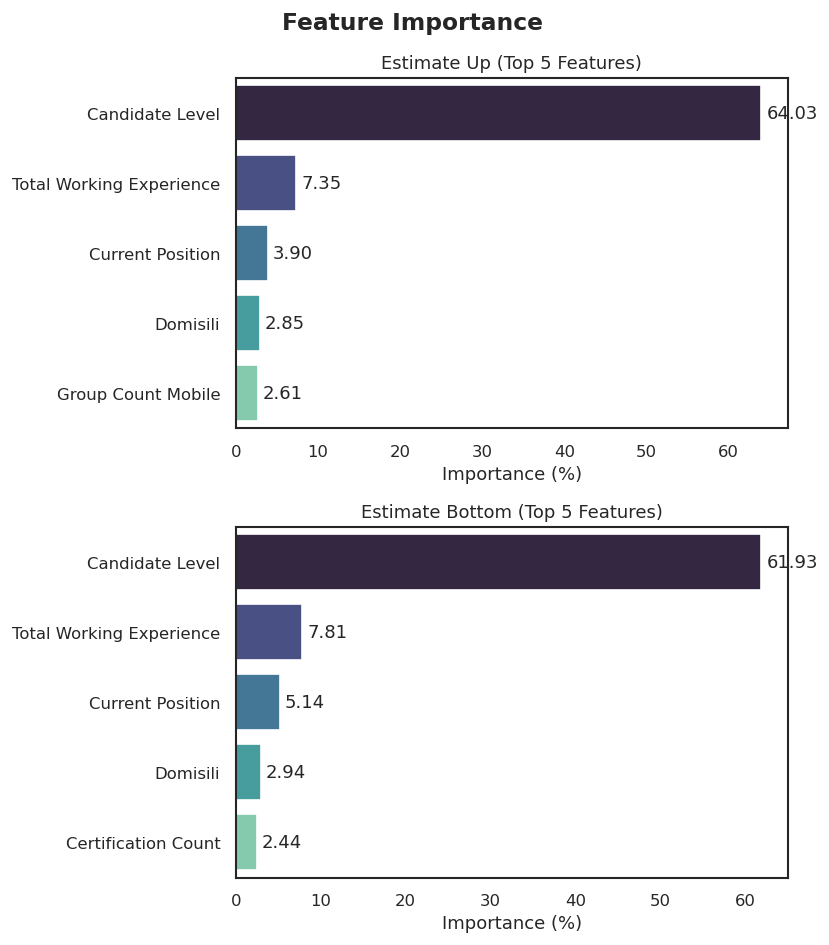

In [62]:
plot_feature_importance(feature_importance_up, feature_importance_bottom, feat_num=5)

##### Aggregated Tech Stack Categorices Feature Importance

In [63]:
GROUP_AGG_NAME = "Tech Stack Categories"

def collapse_group_features(fi_df: pd.DataFrame, feature_col="Feature", imp_col="Importance") -> pd.DataFrame:
    df = fi_df.copy()

    assert feature_col in df.columns and imp_col in df.columns, "Kolom Feature/Importance tidak ditemukan"
    df[feature_col] = df[feature_col].astype(str)
    df[imp_col] = pd.to_numeric(df[imp_col], errors="coerce").fillna(0.0)
    is_group = df[feature_col].str.startswith("Group ")

    if not is_group.any():
        return df.sort_values(imp_col, ascending=False).reset_index(drop=True)

    group_total = df.loc[is_group, imp_col].sum()
    df_non_group = df.loc[~is_group, [feature_col, imp_col]]
    df_group_agg = pd.DataFrame({feature_col: [GROUP_AGG_NAME], imp_col: [group_total]})

    out = (
        pd.concat([df_non_group, df_group_agg], ignore_index=True)
          .sort_values(imp_col, ascending=False)
          .reset_index(drop=True)
    )
    return out

feature_importance_up_grouped = collapse_group_features(feature_importance_up, feature_col="Feature", imp_col="Importance")
feature_importance_bottom_grouped = collapse_group_features(feature_importance_bottom, feature_col="Feature", imp_col="Importance")

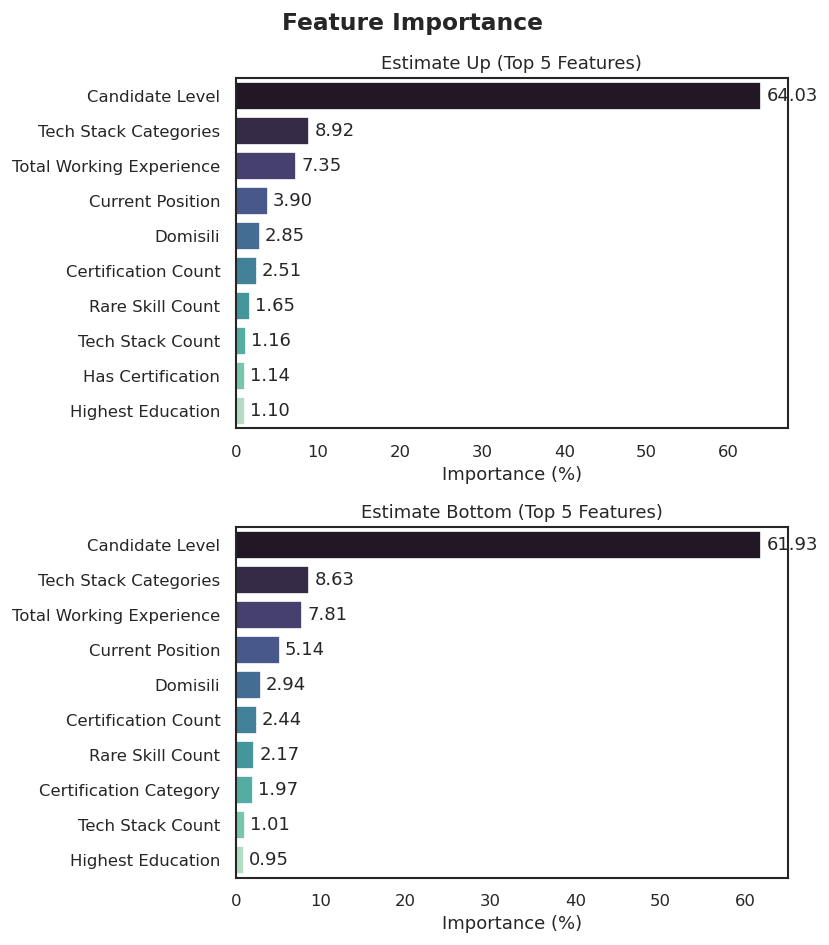

In [64]:
plot_feature_importance(feature_importance_up_grouped, feature_importance_bottom_grouped, feat_num=10)

##### Mean Feature Importance

In [65]:
def average_feature_importance(fi_up: pd.DataFrame, fi_bottom: pd.DataFrame) -> pd.DataFrame:
    fi_up = fi_up.copy()
    fi_bottom = fi_bottom.copy()
    fi_up["Importance"] = pd.to_numeric(fi_up["Importance"], errors="coerce").fillna(0.0)
    fi_bottom["Importance"] = pd.to_numeric(fi_bottom["Importance"], errors="coerce").fillna(0.0)
    
    merged = pd.merge(fi_up, fi_bottom, on="Feature", how="outer", suffixes=("_up", "_bottom")).fillna(0.0)
    merged["Importance"] = (merged["Importance_up"] + merged["Importance_bottom"]) / 2.0
    out = merged[["Feature", "Importance"]].sort_values("Importance", ascending=False).reset_index(drop=True)
    return out

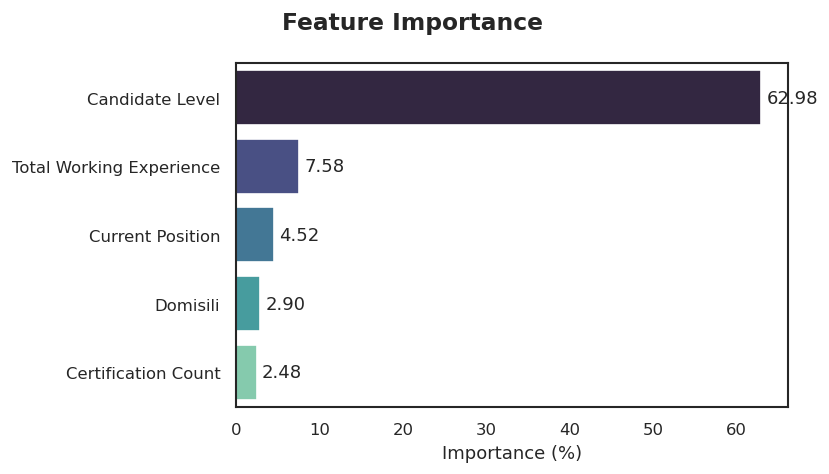

In [66]:
feat_importance = average_feature_importance(feature_importance_up, feature_importance_bottom)

fig, ax = plt.subplots(figsize=(7, 4), dpi=120)

plot_up = sns.barplot(
        data=feat_importance.head(5), 
        y="Feature", x="Importance", 
        palette="mako"
    )

ax.set_xlabel('Importance (%)')
ax.set_ylabel('')
ax.bar_label(plot_up.containers[0], fmt="%.2f", label_type="edge", padding=3)

fig.suptitle("Feature Importance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

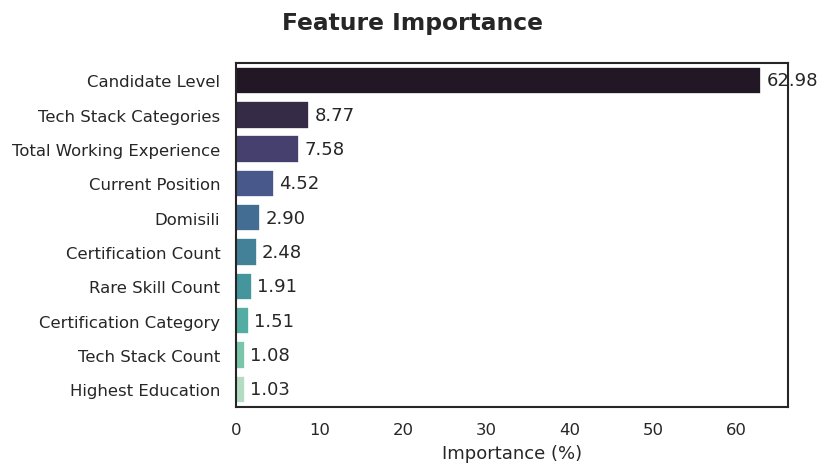

In [67]:
feat_importance_grouped = average_feature_importance(feature_importance_up_grouped, feature_importance_bottom_grouped)

fig, ax = plt.subplots(figsize=(7, 4), dpi=120)

plot_up = sns.barplot(
        data=feat_importance_grouped.head(10), 
        y="Feature", x="Importance", 
        palette="mako"
    )

ax.set_xlabel('Importance (%)')
ax.set_ylabel('')
ax.bar_label(plot_up.containers[0], fmt="%.2f", label_type="edge", padding=3)

fig.suptitle("Feature Importance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#### SHAP

In [68]:
# FE untuk TRAIN (pakai fungsi yang sama supaya konsisten)
X, y_up, y_bottom = get_training_data(train_df)
cat_cols = X.columns[X.dtypes == "object"].tolist()

def fit_catboost_full(X, y, cat_cols, random_seed=RANDOM_SEED):
    model = cb.CatBoostRegressor(
        random_seed=RANDOM_SEED,
        cat_features=cat_cols
    )
    model.fit(X, y, 
             verbose=0,
             early_stopping_rounds=50
    )
    
    return model

model_up     = fit_catboost_full(X, y_up, cat_cols)
model_bottom = fit_catboost_full(X, y_bottom, cat_cols)

In [69]:
explainer = shap.Explainer(model_up)
shap_values = explainer(X)

In [70]:
X.columns

Index(['Total Working Experience', 'Candidate Level',
       'Expected Benefit Bottom', 'Expected Benefit Up', 'Edu Count',
       'Highest Education Ordinal', 'Highest Education',
       'Has Bootcamp or Certificate', 'Is Top Uni', 'Is Foreign Uni',
       'Domisili', 'Has Certification', 'Certification Count',
       'Certification Category', 'Expected Spread', 'Current Position',
       'Targeted Position', 'Tech Stack Count',
       'Group Count Programming Languages', 'Group Count Frontend',
       'Group Count Backend Web', 'Group Count Databases',
       'Group Count Cloud/DevOps', 'Group Count Data/ML',
       'Group Count Testing/QA', 'Group Count Mobile',
       'Group Count Product Design/PM', 'Group Total Covered',
       'Rare Skill Count'],
      dtype='object')

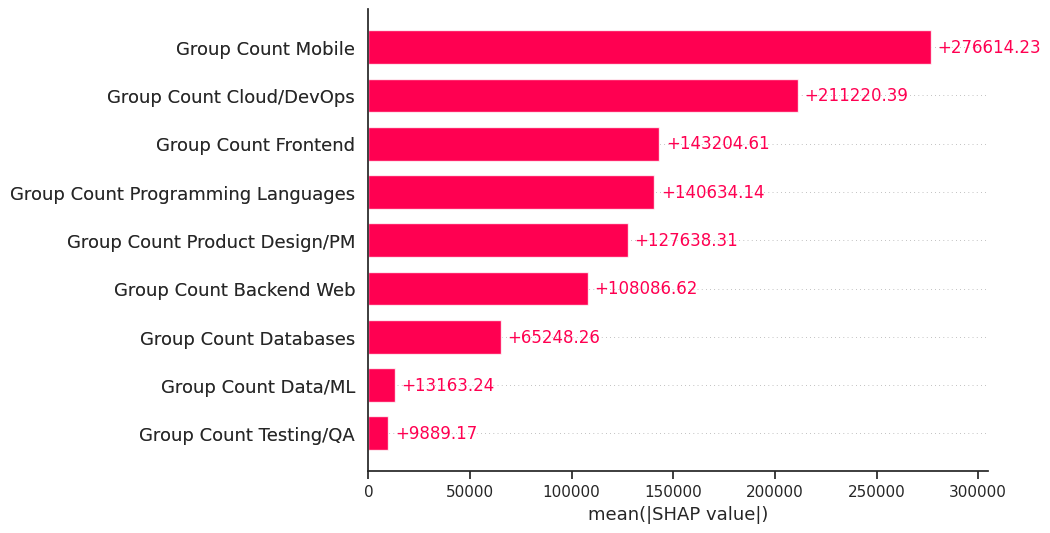

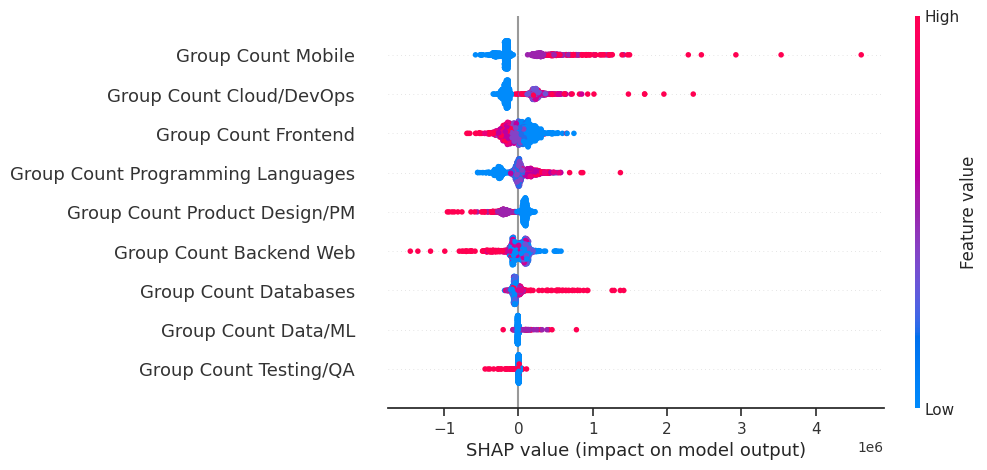

In [71]:
selected_features = [
    'Group Count Programming Languages', 'Group Count Frontend',
    'Group Count Backend Web', 'Group Count Databases',
    'Group Count Cloud/DevOps', 'Group Count Data/ML',
    'Group Count Testing/QA', 'Group Count Mobile',
    'Group Count Product Design/PM'
]
mask = [feat in selected_features for feat in shap_values.feature_names]

shap_selected = shap.Explanation(
    values       = shap_values.values[:, mask],
    base_values  = shap_values.base_values,
    data         = shap_values.data[:, mask],
    feature_names= [f for f in shap_values.feature_names if f in selected_features]
)

shap.plots.bar(shap_selected)
shap.plots.beeswarm(shap_selected)


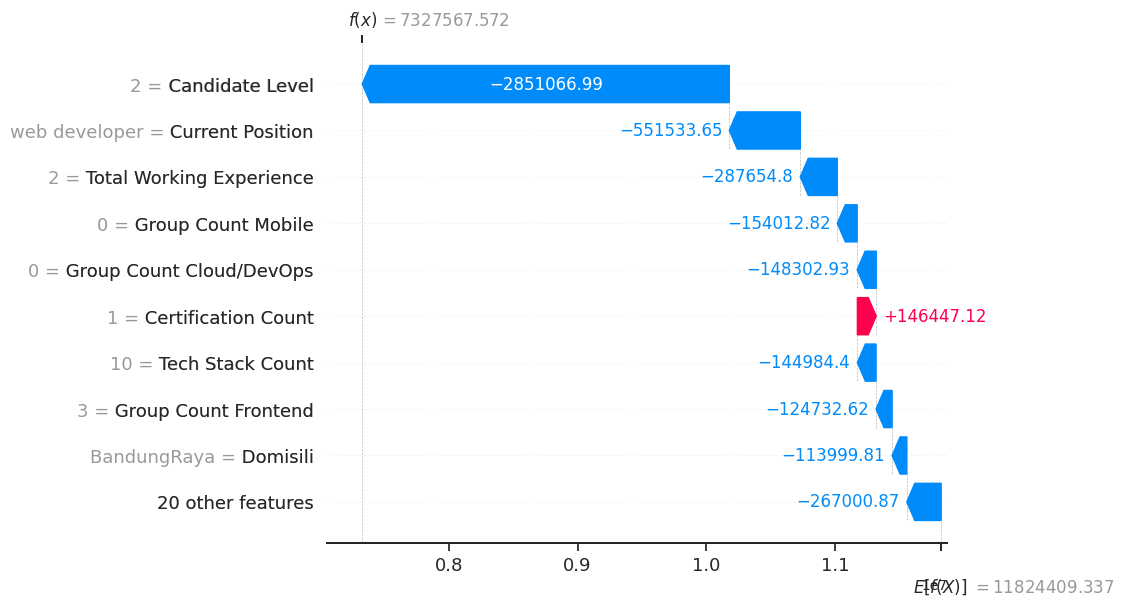

In [72]:
shap.plots.waterfall(shap_values[0])

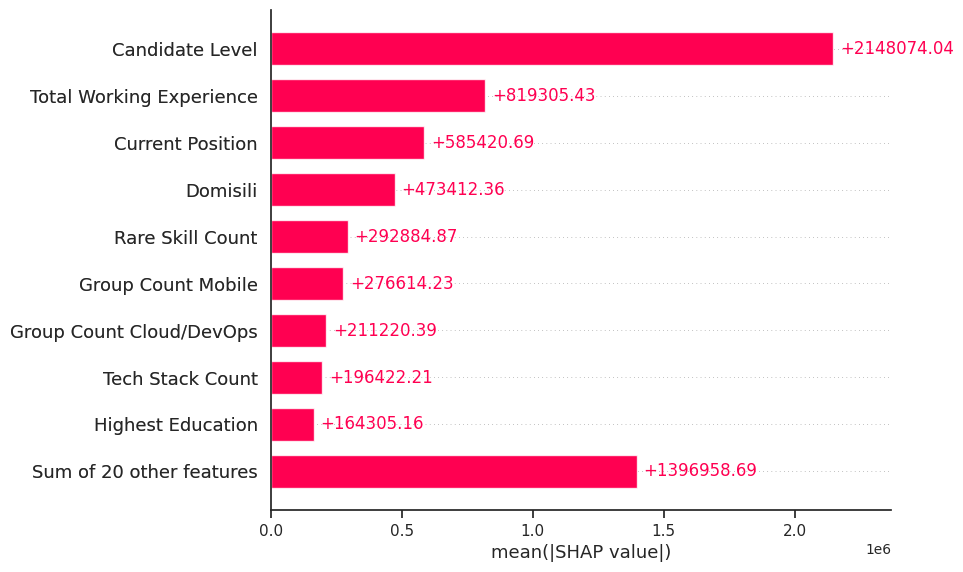

In [73]:
shap.plots.bar(shap_values)

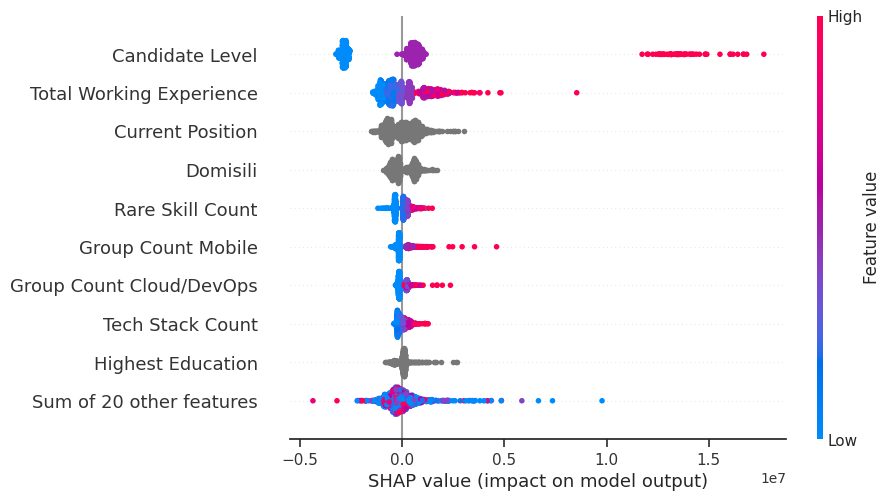

In [74]:
shap.plots.beeswarm(shap_values)

#### Individual Feature Insights

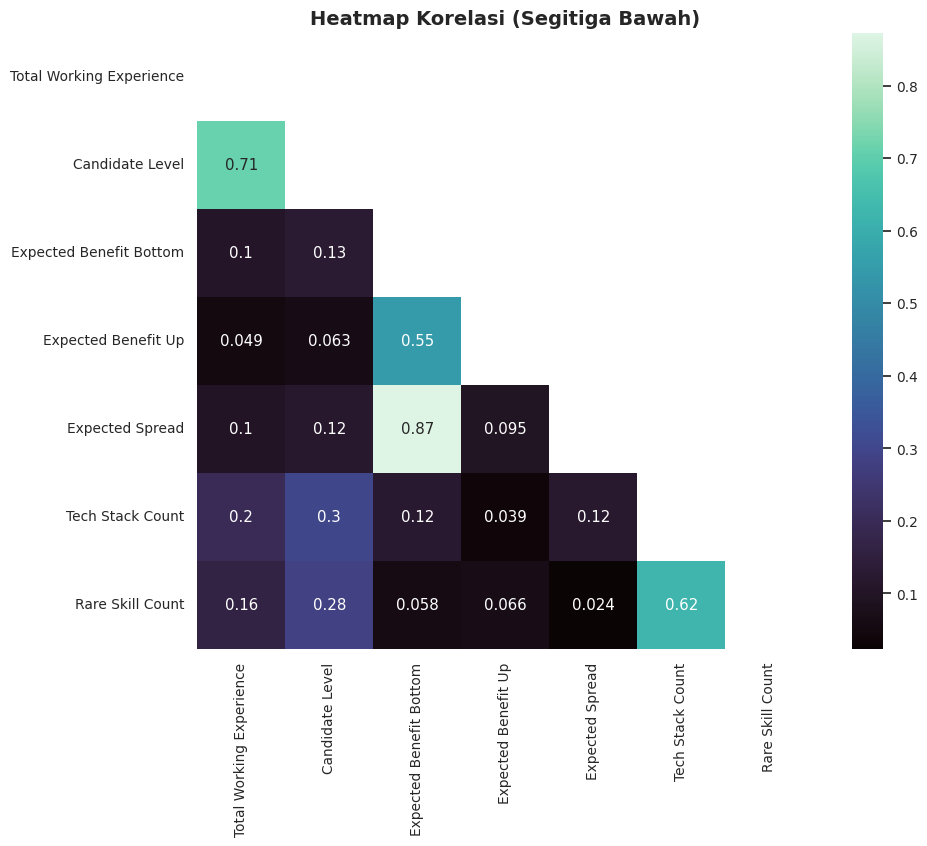

In [75]:
X_heatmap = X[["Total Working Experience", "Candidate Level", "Expected Benefit Bottom", "Expected Benefit Up", "Expected Spread", "Tech Stack Count", "Rare Skill Count"]]
corr = X_heatmap.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10,8))
sns.heatmap(
    corr, 
    mask=mask,      
    annot=True, 
    cmap="mako", 
    square=True
)
plt.title("Heatmap Korelasi (Segitiga Bawah)", fontsize=14, fontweight="bold")
plt.show()

In [76]:
X["Certification Category"].value_counts()

Certification Category
other_cert           486
Unknown              356
programming          128
data_ml               92
network_sysadmin      36
cloud_devops          26
product_design_pm     23
testing_qa             8
security               4
databases              1
Name: count, dtype: int64

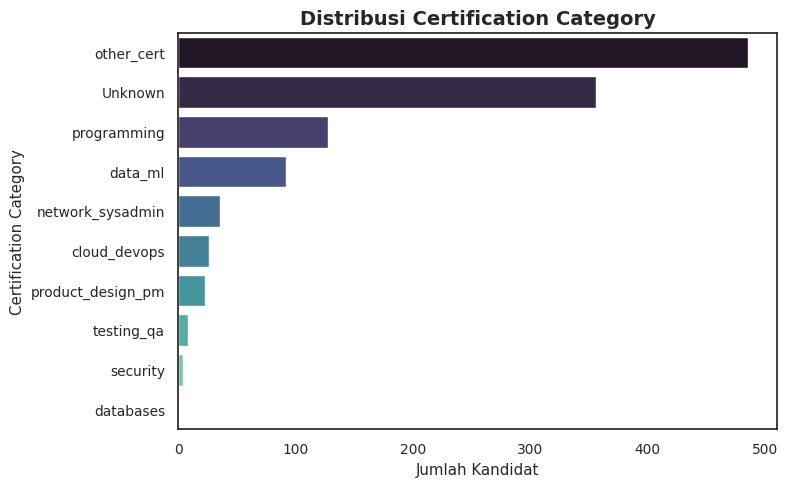

In [77]:
cert_counts = X["Certification Category"].value_counts()

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(y=cert_counts.index, x=cert_counts.values, palette="mako", ax=ax)
ax.set_title("Distribusi Certification Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Jumlah Kandidat")
ax.set_ylabel("Certification Category")
plt.savefig("cert_cat_bar.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [78]:
X[["Highest Education", "Highest Education Ordinal"]].sample(10)

,Highest Education,Highest Education Ordinal
248,S1/D4,3
196,S1/D4,3
681,S1/D4,3
180,S1/D4,3
1114,S1/D4,3
450,S1/D4,3
88,Unknown,0
1078,S1/D4,3
21,S1/D4,3
947,S1/D4,3
